<a href="https://colab.research.google.com/github/awsafbeensalauddin-crypto/Financial-Distress-Early-Warning-System/blob/main/MIS444_Corporate_Bankruptcy_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Corporate Bankruptcy Risk Intelligence

### Predictive Financial Distress Analytics Using Machine Learning

---

**Course:** MIS444 — Predictive Analytics in Business  

**Project Domain:** Accounting, Finance & Management Information Systems  

**Analytics Task:** **Binary Classification**

**Business Objective:**  
Develop a predictive early-warning system that uses corporate financial indicators to identify companies with an elevated risk of bankruptcy.

**Target Variable:** `Bankrupt?`  
- **0** → Non-Bankrupt Company  
- **1** → Bankrupt Company  

**Data Source:** [UCI Machine Learning Repository — Taiwanese Bankruptcy Prediction](https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction)

---

## 🔍 Project Analytics Workflow

**01 — Data Acquisition**  
Collect and understand the corporate bankruptcy dataset.

**02 — Data Quality & Preparation**  
Inspect missing values, duplicates, invalid observations, outliers, class imbalance, and feature scaling.

**03 — Exploratory Financial Analysis**  
Investigate profitability, leverage, liquidity, financial structure, and bankruptcy patterns.

**04 — Predictive Feature Selection**  
Identify the most informative financial indicators while reducing redundant variables.

**05 — Classification Model Development**  
Develop Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine models.

**06 — Hyperparameter Optimization**  
Improve model performance using GridSearchCV and Stratified 5-Fold Cross-Validation.

**07 — Model Validation & Risk Evaluation**  
Compare Accuracy, Precision, Recall, F1-score, ROC-AUC, confusion matrices, and validation stability.

**08 — Business Decision Support**  
Translate predictive results into recommendations for banks, auditors, investors, managers, and trade-credit providers.

---

### 🎯 Project Goal

> **Transform historical financial information into an actionable corporate financial-distress early-warning system.**

# 1. Data Collection

The dataset was obtained from the **UCI Machine Learning Repository**. It contains **6,819 corporate records** with **95 financial indicators** related to profitability, liquidity, leverage, solvency, operating efficiency, and financial structure.

The target variable is `Bankrupt?`, where:

- **0 = Non-Bankrupt Company**
- **1 = Bankrupt Company**

The purpose of this project is to use financial indicators to predict whether a company is at risk of bankruptcy.

| Feature | Description |
|---|---|
| ROA(C) | Return on assets before interest and depreciation |
| Operating Gross Margin | Measures operating profitability |
| Cash Flow Rate | Measures cash-flow performance |
| Debt Ratio % | Measures financial leverage |
| Current Liability to Assets | Short-term liabilities relative to assets |
| Net Income to Total Assets | Profitability relative to total assets |
| Liability to Equity | Liabilities relative to shareholders' equity |
| Interest Coverage Ratio | Ability to cover interest expense |
| Equity to Liability | Equity relative to liabilities |
| Bankrupt? | **Target variable — 1 = Bankrupt, 0 = Non-Bankrupt** |

In [ ]:
# ── Importing necessary libraries ──────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Define dataset path
file_path = '/content/drive/MyDrive/MIS444_Project/data.csv'

# Check whether file exists and load dataset
if os.path.exists(file_path):
    bankruptcy = pd.read_csv(file_path)
    bankruptcy_original = bankruptcy.copy()

    print(f"✅ Dataset loaded successfully. Shape: {bankruptcy.shape}")
    display(bankruptcy.head(10))
else:
    print(f"❌ File not found at: {file_path}")
    print("Please check the file location in Google Drive.")

Mounted at /content/drive
✅ Dataset loaded successfully. Shape: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
5,1,0.388680,0.415177,0.419134,0.590171,0.590251,0.998758,0.796903,0.808771,0.303116,...,0.710420,0.005278,0.622605,0.590172,0.829939,0.285087,0.026675,0.564538,1,0.019534
6,0,0.390923,0.445704,0.436158,0.619950,0.619950,0.998993,0.797012,0.808960,0.302814,...,0.736619,0.018372,0.623655,0.619949,0.829980,0.292504,0.026622,0.564200,1,0.015663
7,0,0.508361,0.570922,0.559077,0.601738,0.601717,0.999009,0.797449,0.809362,0.303545,...,0.815350,0.010005,0.623843,0.601739,0.841459,0.278607,0.027031,0.566089,1,0.034889
8,0,0.488519,0.545137,0.543284,0.603612,0.603612,0.998961,0.797414,0.809338,0.303584,...,0.803647,0.000824,0.623977,0.603613,0.840487,0.276423,0.026891,0.565592,1,0.065826
9,0,0.495686,0.550916,0.542963,0.599209,0.599209,0.999001,0.797404,0.809320,0.303483,...,0.804195,0.005798,0.623865,0.599205,0.840688,0.279388,0.027243,0.566668,1,0.030801


# 2. Data Preprocessing

Data preprocessing ensures that the financial dataset is clean, consistent, and suitable for predictive modeling.

The following preprocessing steps are performed:

- Standardize column names
- Inspect dataset structure and data types
- Check for missing values
- Check for duplicate observations
- Identify and remove constant or non-informative features
- Check for infinite and unusual numerical values
- Examine the distribution of the target variable
- Detect potential outliers in financial indicators
- Split the dataset into training and testing sets using stratification
- Scale numerical predictors using StandardScaler

> **Note:** One-Hot Encoding is not required because all predictor variables in this dataset are numerical.


In [ ]:
# ── Step 2.1: Standardize column names ─────────────────────────────────────

# Remove unnecessary spaces from the beginning and end of column names
bankruptcy.columns = bankruptcy.columns.str.strip()

print("✅ Column names standardized successfully.")
print(f"Total columns: {len(bankruptcy.columns)}")

print("\nFirst 15 column names:")
for col in bankruptcy.columns[:15]:
    print("•", col)

✅ Column names standardized successfully.
Total columns: 96

First 15 column names:
• Bankrupt?
• ROA(C) before interest and depreciation before interest
• ROA(A) before interest and % after tax
• ROA(B) before interest and depreciation after tax
• Operating Gross Margin
• Realized Sales Gross Margin
• Operating Profit Rate
• Pre-tax net Interest Rate
• After-tax net Interest Rate
• Non-industry income and expenditure/revenue
• Continuous interest rate (after tax)
• Operating Expense Rate
• Research and development expense rate
• Cash flow rate
• Interest-bearing debt interest rate


In [ ]:
# ── Step 2.2: Inspect dataset structure and data types ─────────────────────

print("=== DATASET STRUCTURE ===")
print(f"Number of rows        : {bankruptcy.shape[0]:,}")
print(f"Number of columns     : {bankruptcy.shape[1]}")
print(f"Predictor variables   : {bankruptcy.shape[1] - 1}")
print("Target variable       : Bankrupt?")

print("\n=== DATA TYPE SUMMARY ===")
print(bankruptcy.dtypes.value_counts())

=== DATASET STRUCTURE ===
Number of rows        : 6,819
Number of columns     : 96
Predictor variables   : 95
Target variable       : Bankrupt?

=== DATA TYPE SUMMARY ===
float64    93
int64       3
Name: count, dtype: int64


In [ ]:
# ── Step 2.3: Inspect missing values ───────────────────────────────────────

missing_values = bankruptcy.isnull().sum()
missing_columns = missing_values[missing_values > 0]

print("=== MISSING VALUE CHECK ===")
print(f"Total missing values             : {bankruptcy.isnull().sum().sum()}")
print(f"Columns containing missing values: {len(missing_columns)}")

if len(missing_columns) > 0:
    display(missing_columns.sort_values(ascending=False))
else:
    print("✅ No missing values detected. No imputation is required.")

=== MISSING VALUE CHECK ===
Total missing values             : 0
Columns containing missing values: 0
✅ No missing values detected. No imputation is required.


In [ ]:
# ── Step 2.4: Check duplicate observations ─────────────────────────────────

duplicate_count = bankruptcy.duplicated().sum()

print("=== DUPLICATE CHECK ===")
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    bankruptcy.drop_duplicates(inplace=True)
    print("✅ Duplicate observations removed.")
    print(f"New dataset shape: {bankruptcy.shape}")
else:
    print("✅ No duplicate observations found.")

=== DUPLICATE CHECK ===
Duplicate rows found: 0
✅ No duplicate observations found.


In [ ]:
# ── Step 2.5: Identify constant / non-informative features ─────────────────

constant_columns = [
    col for col in bankruptcy.columns
    if bankruptcy[col].nunique(dropna=False) <= 1
]

print("=== CONSTANT FEATURE CHECK ===")
print(f"Constant features found: {len(constant_columns)}")

if constant_columns:
    print("\nConstant feature(s):")
    for col in constant_columns:
        print("•", col)
else:
    print("✅ No constant features detected.")

=== CONSTANT FEATURE CHECK ===
Constant features found: 1

Constant feature(s):
• Net Income Flag


In [ ]:
# ── Step 2.5b: Remove constant / non-informative features ─────────────────

print("=== REMOVING CONSTANT FEATURES ===")

if constant_columns:
    print("Removing:")
    for col in constant_columns:
        print("•", col)

    bankruptcy.drop(columns=constant_columns, inplace=True)

    print("\n✅ Constant feature(s) removed.")
    print(f"Updated dataset shape: {bankruptcy.shape}")
else:
    print("✅ No constant features need to be removed.")

=== REMOVING CONSTANT FEATURES ===
Removing:
• Net Income Flag

✅ Constant feature(s) removed.
Updated dataset shape: (6819, 95)


In [ ]:
# ── Step 2.6: Check infinite numerical values ──────────────────────────────

numeric_data = bankruptcy.select_dtypes(include=np.number)

infinite_count = np.isinf(numeric_data).sum().sum()

print("=== INFINITE VALUE CHECK ===")
print(f"Total infinite values: {infinite_count}")

if infinite_count == 0:
    print("✅ No positive or negative infinite values detected.")
else:
    print("⚠️ Infinite values detected and require treatment.")

=== INFINITE VALUE CHECK ===
Total infinite values: 0
✅ No positive or negative infinite values detected.


In [ ]:
# ── Step 2.7: Inspect negative numerical values ────────────────────────────

feature_data = bankruptcy.drop(columns='Bankrupt?')

negative_counts = (feature_data < 0).sum()
negative_columns = negative_counts[negative_counts > 0]

print("=== NEGATIVE VALUE CHECK ===")
print(f"Features containing negative values: {len(negative_columns)}")

if len(negative_columns) > 0:
    display(negative_columns.sort_values(ascending=False))
    print("⚠️ Negative values should be reviewed before any treatment.")
else:
    print("✅ No negative values detected in the predictor variables.")

=== NEGATIVE VALUE CHECK ===
Features containing negative values: 0
✅ No negative values detected in the predictor variables.


In [ ]:
# ── Step 2.8: Inspect target class distribution ────────────────────────────

class_counts = bankruptcy['Bankrupt?'].value_counts().sort_index()

class_percentages = (
    bankruptcy['Bankrupt?']
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages.round(2)
})

target_summary.index = [
    'Non-Bankrupt (0)',
    'Bankrupt (1)'
]

print("=== TARGET CLASS DISTRIBUTION ===")
display(target_summary)

=== TARGET CLASS DISTRIBUTION ===


,Count,Percentage (%)
Non-Bankrupt (0),6599,96.77
Bankrupt (1),220,3.23


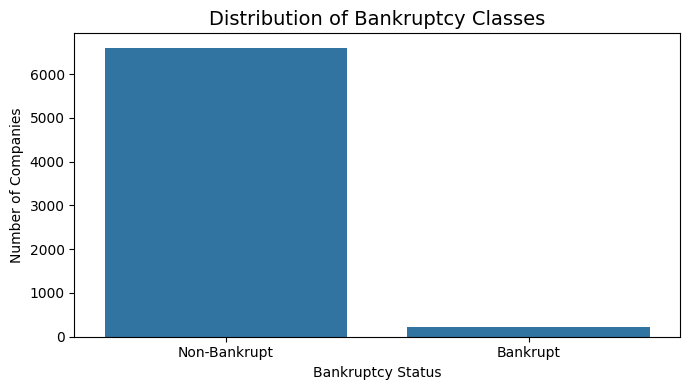

In [ ]:
# ── Step 2.8b: Visualize target class distribution ────────────────────────

plt.figure(figsize=(7, 4))

sns.countplot(
    x='Bankrupt?',
    data=bankruptcy
)

plt.title('Distribution of Bankruptcy Classes', fontsize=14)
plt.xlabel('Bankruptcy Status')
plt.ylabel('Number of Companies')
plt.xticks([0, 1], ['Non-Bankrupt', 'Bankrupt'])

plt.tight_layout()
plt.show()

### Interpretation

The target variable is highly imbalanced. Approximately **96.77%** of companies are non-bankrupt, while only **3.23%** are bankrupt.

Therefore, **accuracy alone may be misleading**. A model that predicts every company as non-bankrupt could still achieve very high accuracy. For this reason, Precision, Recall, F1-score, and ROC-AUC will also be emphasized during model evaluation.

In [ ]:
# ── Step 2.9: Detect potential outliers using the IQR method ───────────────

feature_columns = bankruptcy.drop(columns='Bankrupt?').columns

outlier_summary = []

for col in feature_columns:

    Q1 = bankruptcy[col].quantile(0.25)
    Q3 = bankruptcy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (bankruptcy[col] < lower_bound) |
        (bankruptcy[col] > upper_bound)
    ).sum()

    outlier_summary.append([col, outlier_count])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=['Feature', 'Potential Outliers']
)

outlier_summary = outlier_summary.sort_values(
    by='Potential Outliers',
    ascending=False
)

print("=== TOP 10 FEATURES WITH POTENTIAL OUTLIERS ===")
display(outlier_summary.head(10))

=== TOP 10 FEATURES WITH POTENTIAL OUTLIERS ===


,Feature,Potential Outliers
91,Degree of Financial Leverage (DFL),1503
92,Interest Coverage Ratio (Interest expense to E...,1421
48,Fixed Assets Turnover Frequency,1418
70,Current Asset Turnover Rate,1399
28,Total Asset Growth Rate,1381
34,Interest Expense Ratio,1362
80,Cash Flow to Liability,1212
87,No-credit Interval,1139
8,Non-industry income and expenditure/revenue,1094
74,Cash Flow to Sales,1052


### Outlier Treatment Decision

The IQR method identified potential extreme observations in several financial indicators.

However, these observations are **not automatically removed or capped** because extreme financial ratios may represent genuine financially distressed companies rather than data-entry errors. Removing them could eliminate important bankruptcy warning signals.

Therefore, the observations are retained, while scaling and robust modeling techniques will be considered during model development.

In [ ]:
# ── Step 2.10: Separate predictor variables and target ─────────────────────

X = bankruptcy.drop(columns='Bankrupt?')
y = bankruptcy['Bankrupt?']

print("=== FEATURES AND TARGET ===")
print(f"Predictor matrix shape: {X.shape}")
print(f"Target vector shape    : {y.shape}")

print(f"\nNumber of predictors: {X.shape[1]}")

=== FEATURES AND TARGET ===
Predictor matrix shape: (6819, 94)
Target vector shape    : (6819,)

Number of predictors: 94


In [ ]:
# ── Step 2.11: Stratified train/test split ─────────────────────────────────

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("✅ Stratified train/test split completed.")

print(f"\nX_train shape: {X_train_raw.shape}")
print(f"X_test shape : {X_test_raw.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

✅ Stratified train/test split completed.

X_train shape: (5114, 94)
X_test shape : (1705, 94)
y_train shape: (5114,)
y_test shape : (1705,)

Training target distribution:
Bankrupt?
0    4949
1     165
Name: count, dtype: int64

Testing target distribution:
Bankrupt?
0    1650
1      55
Name: count, dtype: int64


In [ ]:
# ── Step 2.12: Scale numerical predictors ──────────────────────────────────

scaler = StandardScaler()

# Learn scaling parameters ONLY from training data
X_train_scaled = scaler.fit_transform(X_train_raw)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test_raw)

# Convert scaled arrays back into DataFrames
X_train = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train_raw.index
)

X_test = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test_raw.index
)

print("✅ Feature scaling completed.")
print("✅ Scaler fitted on training data only.")

print(f"\nScaled training shape: {X_train.shape}")
print(f"Scaled testing shape : {X_test.shape}")

✅ Feature scaling completed.
✅ Scaler fitted on training data only.

Scaled training shape: (5114, 94)
Scaled testing shape : (1705, 94)


In [ ]:
# ── Step 2.13: Final preprocessing summary ─────────────────────────────────

print("=" * 60)
print("          DATA PREPROCESSING SUMMARY")
print("=" * 60)

print(f"Original dataset shape       : {bankruptcy_original.shape}")
print(f"Cleaned dataset shape        : {bankruptcy.shape}")

print(f"Missing values               : {bankruptcy.isnull().sum().sum()}")
print(f"Duplicate rows               : {bankruptcy.duplicated().sum()}")

print(f"Predictor variables retained : {X.shape[1]}")
print("Target variable              : Bankrupt?")

print(f"Training observations        : {X_train.shape[0]}")
print(f"Testing observations         : {X_test.shape[0]}")

print("\n✅ Dataset is ready for exploratory analysis and modeling.")

          DATA PREPROCESSING SUMMARY
Original dataset shape       : (6819, 96)
Cleaned dataset shape        : (6819, 95)
Missing values               : 0
Duplicate rows               : 0
Predictor variables retained : 94
Target variable              : Bankrupt?
Training observations        : 5114
Testing observations         : 1705

✅ Dataset is ready for exploratory analysis and modeling.


### Preprocessing Summary

The dataset required relatively limited cleaning because no missing values, duplicate observations, infinite values, or negative predictor values were detected.

One constant feature, `Net Income Flag`, was removed because it contained no variation and therefore provided no predictive information.

The target variable was found to be highly imbalanced, with only **3.23% bankrupt companies**. Therefore, a stratified train-test split was used to preserve the class distribution in both datasets.

Potential outliers were identified but retained because extreme financial indicators may represent genuine financial distress rather than data-entry errors.

Finally, numerical predictors were standardized using parameters learned only from the training data to prevent data leakage.

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to identify financial patterns and relationships associated with corporate bankruptcy.

Because the dataset contains a binary target variable and numerical financial indicators, the analysis focuses on:

- Comparing financial characteristics of bankrupt and non-bankrupt companies
- Examining profitability, leverage, and liability-related indicators
- Identifying variables most strongly associated with bankruptcy
- Exploring relationships among important financial indicators
- Translating statistical patterns into accounting and financial-risk insights

In [1]:
# ── Global Visualization Theme: Financial Intelligence ─────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

# Professional finance-oriented colors
FINANCE_COLORS = {
    'navy':   '#17324D',
    'teal':   '#1F9E89',
    'gold':   '#F4B942',
    'coral':  '#E76F51',
    'purple': '#6C63FF',
    'sky':    '#4EA8DE',
    'gray':   '#6B7280',
    'light':  '#F5F7FA'
}

FINANCE_PALETTE = [
    FINANCE_COLORS['navy'],
    FINANCE_COLORS['teal'],
    FINANCE_COLORS['gold'],
    FINANCE_COLORS['coral'],
    FINANCE_COLORS['purple'],
    FINANCE_COLORS['sky']
]

# Fixed colors for bankruptcy classes
CLASS_COLORS = {
    0: FINANCE_COLORS['teal'],
    1: FINANCE_COLORS['coral']
}

sns.set_theme(
    style='whitegrid',
    context='notebook',
    palette=FINANCE_PALETTE
)

plt.rcParams.update({
    'figure.figsize': (9, 5),
    'figure.dpi': 120,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.20,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

print("✅ Financial Intelligence visualization theme activated.")

✅ Financial Intelligence visualization theme activated.


In [ ]:
# ── EDA 3.1: Prepare data for visualization ────────────────────────────────

eda_df = bankruptcy.copy()

# Create readable labels only for visualization
eda_df['Company Status'] = eda_df['Bankrupt?'].map({
    0: 'Non-Bankrupt',
    1: 'Bankrupt'
})

# Define colors for company status
FINANCE_COLORS = {
    'teal': '#20B2AA',
    'coral': '#FF7F50'
}

STATUS_COLORS = {
    'Non-Bankrupt': FINANCE_COLORS['teal'],
    'Bankrupt': FINANCE_COLORS['coral']
}

print("✅ EDA visualization dataset prepared.")
print(f"Shape: {eda_df.shape}")

✅ EDA visualization dataset prepared.
Shape: (6819, 96)


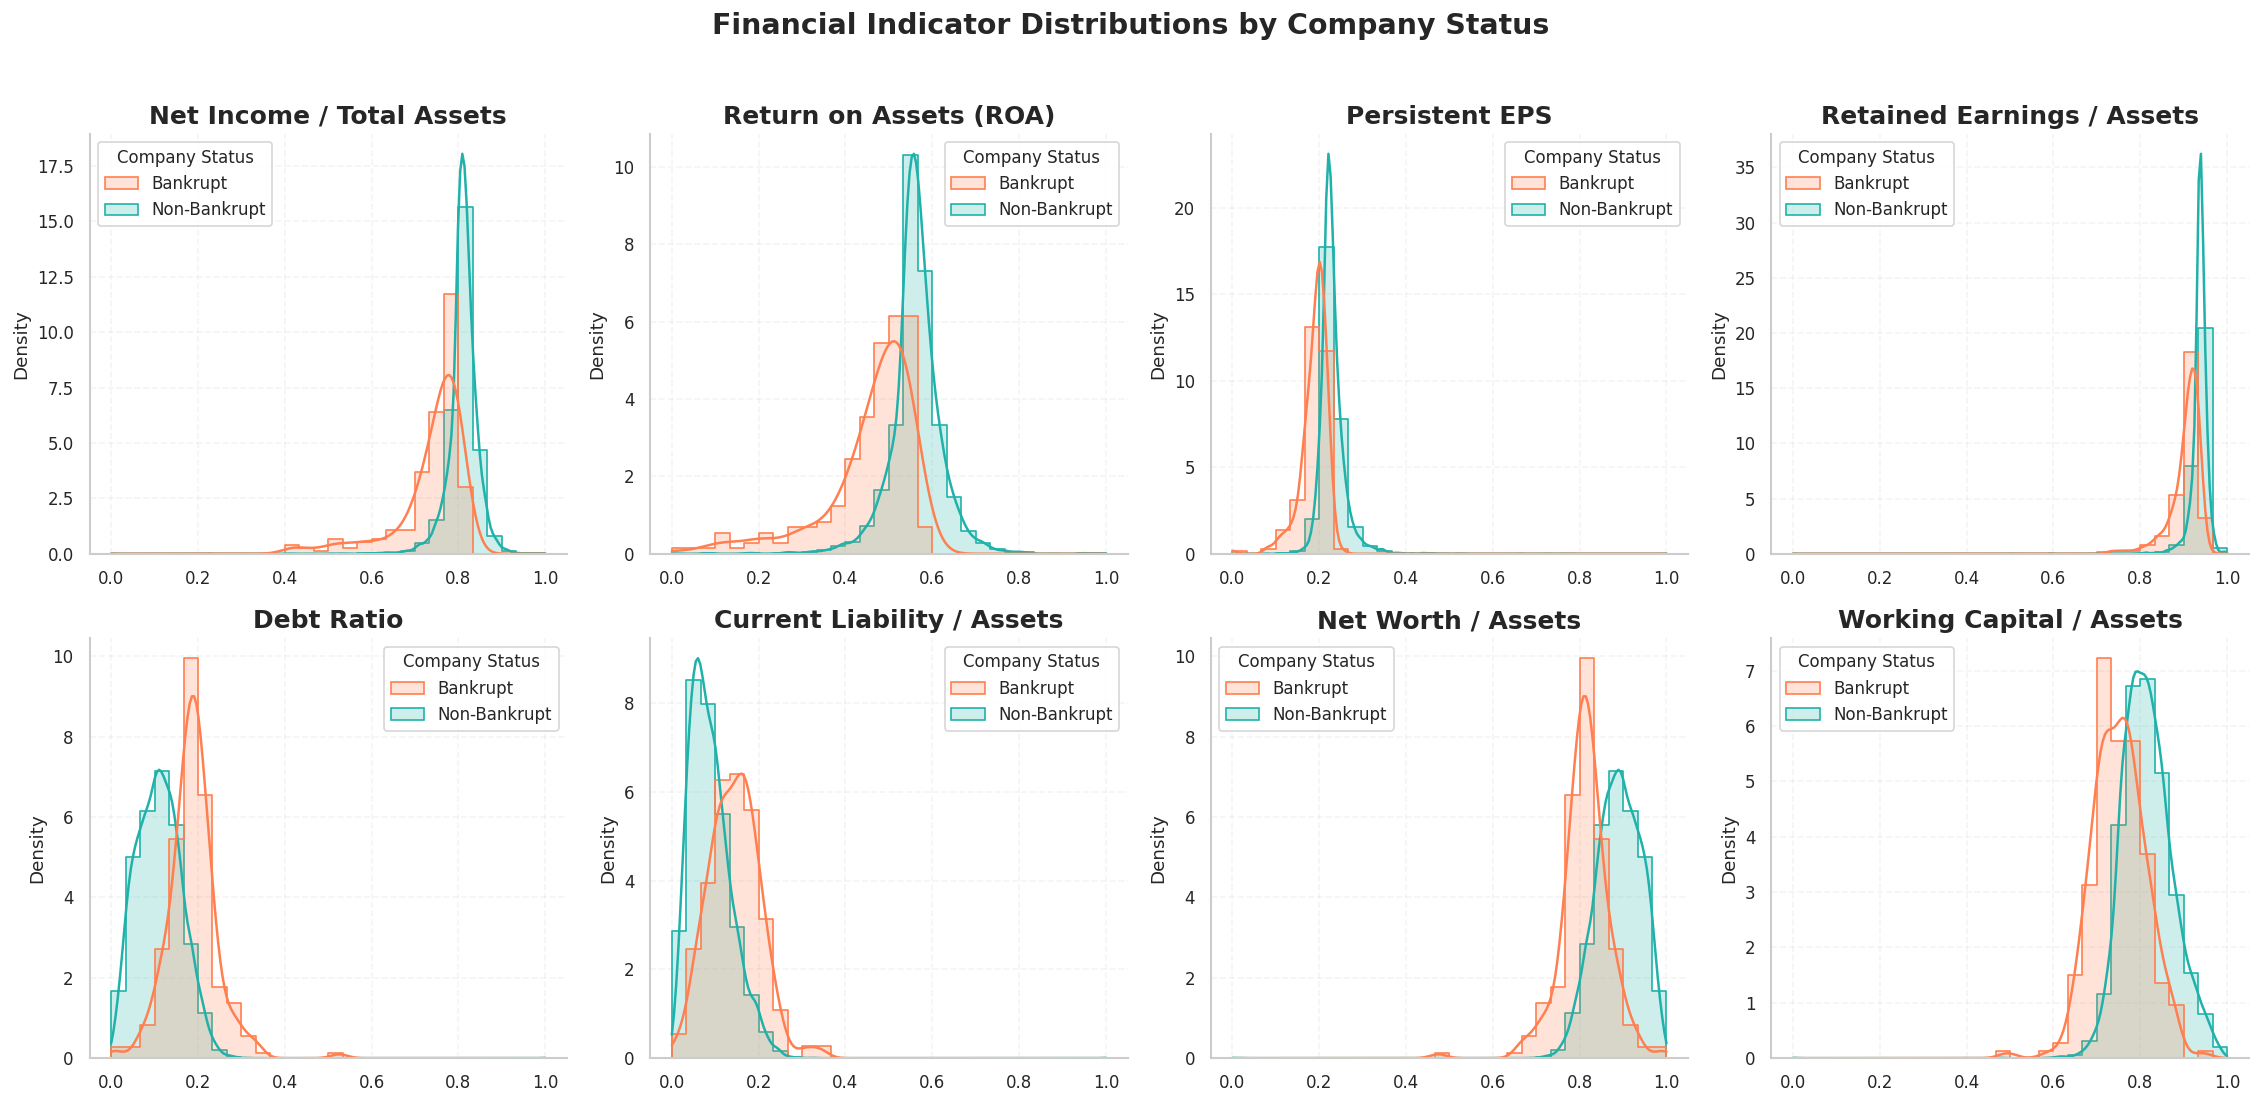

In [ ]:
# ── EDA 3.2: Distribution of key financial indicators ─────────────────────

distribution_features = {
    'Net Income to Total Assets': 'Net Income / Total Assets',
    'ROA(A) before interest and % after tax': 'Return on Assets (ROA)',
    'Persistent EPS in the Last Four Seasons': 'Persistent EPS',
    'Retained Earnings to Total Assets': 'Retained Earnings / Assets',
    'Debt ratio %': 'Debt Ratio',
    'Current Liability to Assets': 'Current Liability / Assets',
'Net worth/Assets': 'Net Worth / Assets',
'Working Capital to Total Assets': 'Working Capital / Assets'
}

fig, axes = plt.subplots(2, 4, figsize=(19, 9))
axes = axes.flatten()

for ax, (feature, short_name) in zip(axes, distribution_features.items()):

    sns.histplot(
        data=eda_df,
        x=feature,
        hue='Company Status',
        palette=STATUS_COLORS,
        stat='density',
        common_norm=False,
        element='step',
        kde=True,
        bins=30,
        alpha=0.22,
        ax=ax
    )

    ax.set_title(short_name, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density')

fig.suptitle(
    'Financial Indicator Distributions by Company Status',
    fontsize=17,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Insight

The distributions indicate that bankrupt and non-bankrupt companies differ across several important financial indicators.

Bankrupt companies generally show weaker profitability measures, including lower return on assets, net income relative to total assets, persistent earnings, and retained earnings. In contrast, financially distressed companies tend to show greater leverage and liability-related pressure.

These differences suggest that both **profitability deterioration** and **financial leverage** may provide useful early-warning signals of bankruptcy.

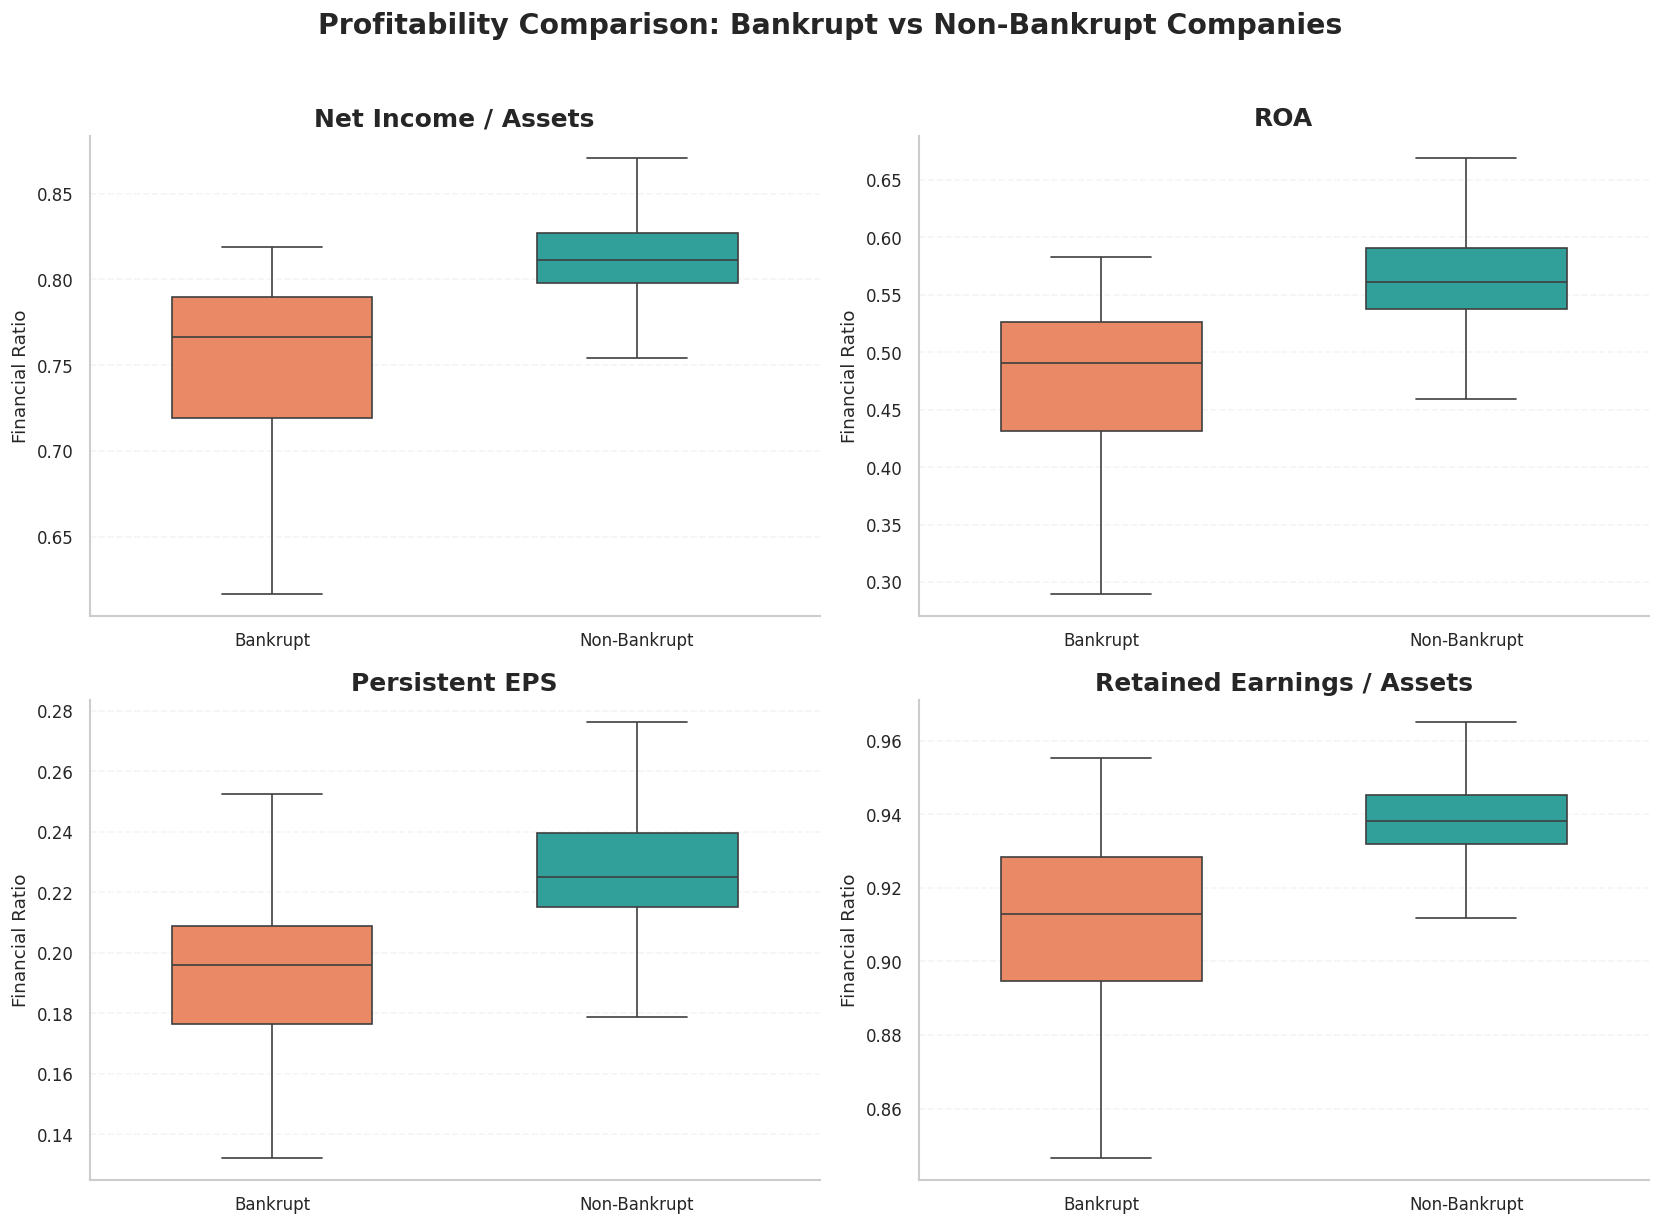

In [ ]:
# ── EDA 3.3: Profitability indicators by bankruptcy status ─────────────────

profitability_features = {
    'Net Income to Total Assets': 'Net Income / Assets',
    'ROA(A) before interest and % after tax': 'ROA',
    'Persistent EPS in the Last Four Seasons': 'Persistent EPS',
    'Retained Earnings to Total Assets': 'Retained Earnings / Assets'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (feature, short_name) in zip(axes, profitability_features.items()):

    sns.boxplot(
        data=eda_df,
        x='Company Status',
        y=feature,
        hue='Company Status',
        palette=STATUS_COLORS,
        legend=False,
        showfliers=False,
        width=0.55,
        ax=ax
    )

    ax.set_title(short_name, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Financial Ratio')

fig.suptitle(
    'Profitability Comparison: Bankrupt vs Non-Bankrupt Companies',
    fontsize=17,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Insight

Bankrupt companies display lower profitability across the selected measures.

The median values of **ROA, Net Income to Total Assets, Persistent EPS, and Retained Earnings to Total Assets** are lower among bankrupt firms. This supports the financial principle that sustained deterioration in profitability and accumulated earnings can signal increasing financial distress.

> Outliers are hidden in these boxplots only to improve visual readability; they remain retained in the dataset.

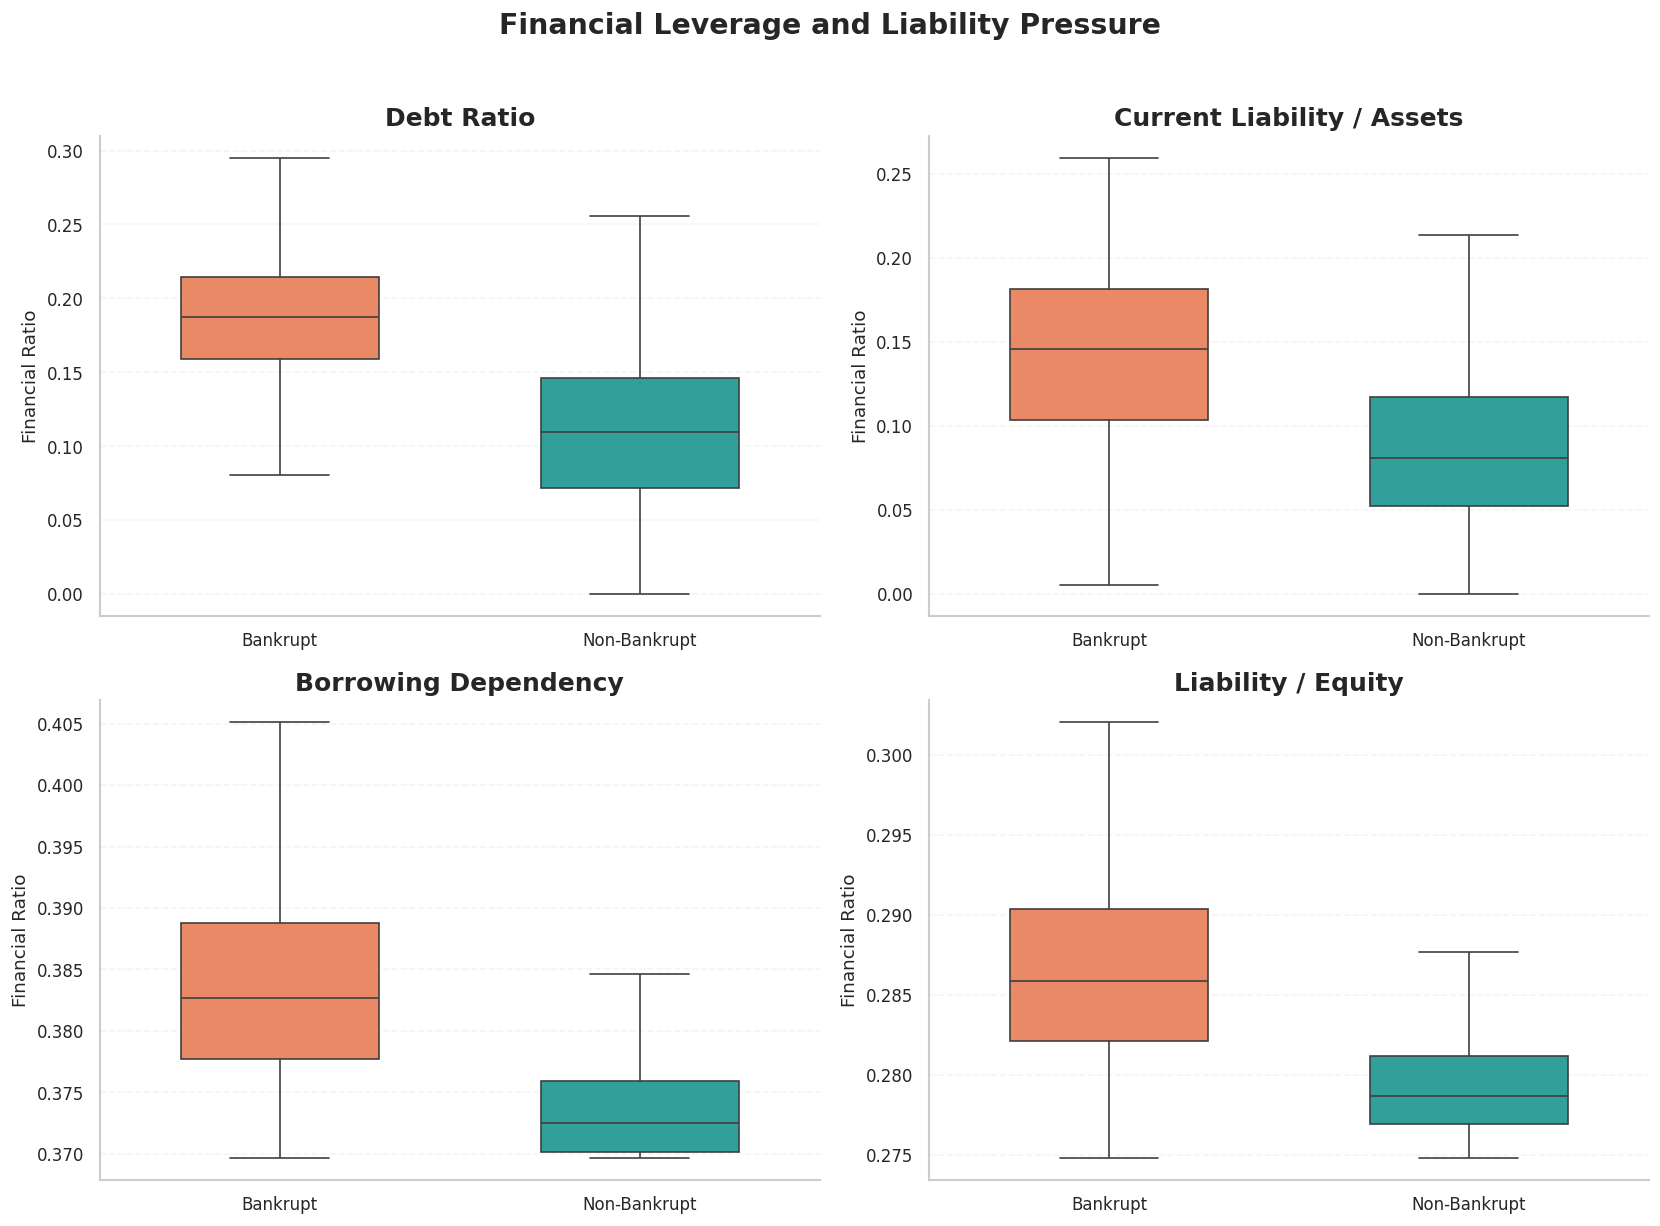

In [ ]:
# ── EDA 3.4: Leverage and liability indicators ─────────────────────────────

risk_features = {
    'Debt ratio %': 'Debt Ratio',
    'Current Liability to Assets': 'Current Liability / Assets',
    'Borrowing dependency': 'Borrowing Dependency',
    'Liability to Equity': 'Liability / Equity'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (feature, short_name) in zip(axes, risk_features.items()):

    sns.boxplot(
        data=eda_df,
        x='Company Status',
        y=feature,
        hue='Company Status',
        palette=STATUS_COLORS,
        legend=False,
        showfliers=False,
        width=0.55,
        ax=ax
    )

    ax.set_title(short_name, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Financial Ratio')

fig.suptitle(
    'Financial Leverage and Liability Pressure',
    fontsize=17,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Insight

Bankrupt companies generally exhibit greater financial pressure.

In particular, the distributions indicate higher **Debt Ratio**, **Current Liability to Assets**, **Borrowing Dependency**, and **Liability to Equity** among financially distressed firms.

From an accounting perspective, excessive reliance on liabilities can weaken financial flexibility and increase the probability that a company will struggle to meet its obligations.


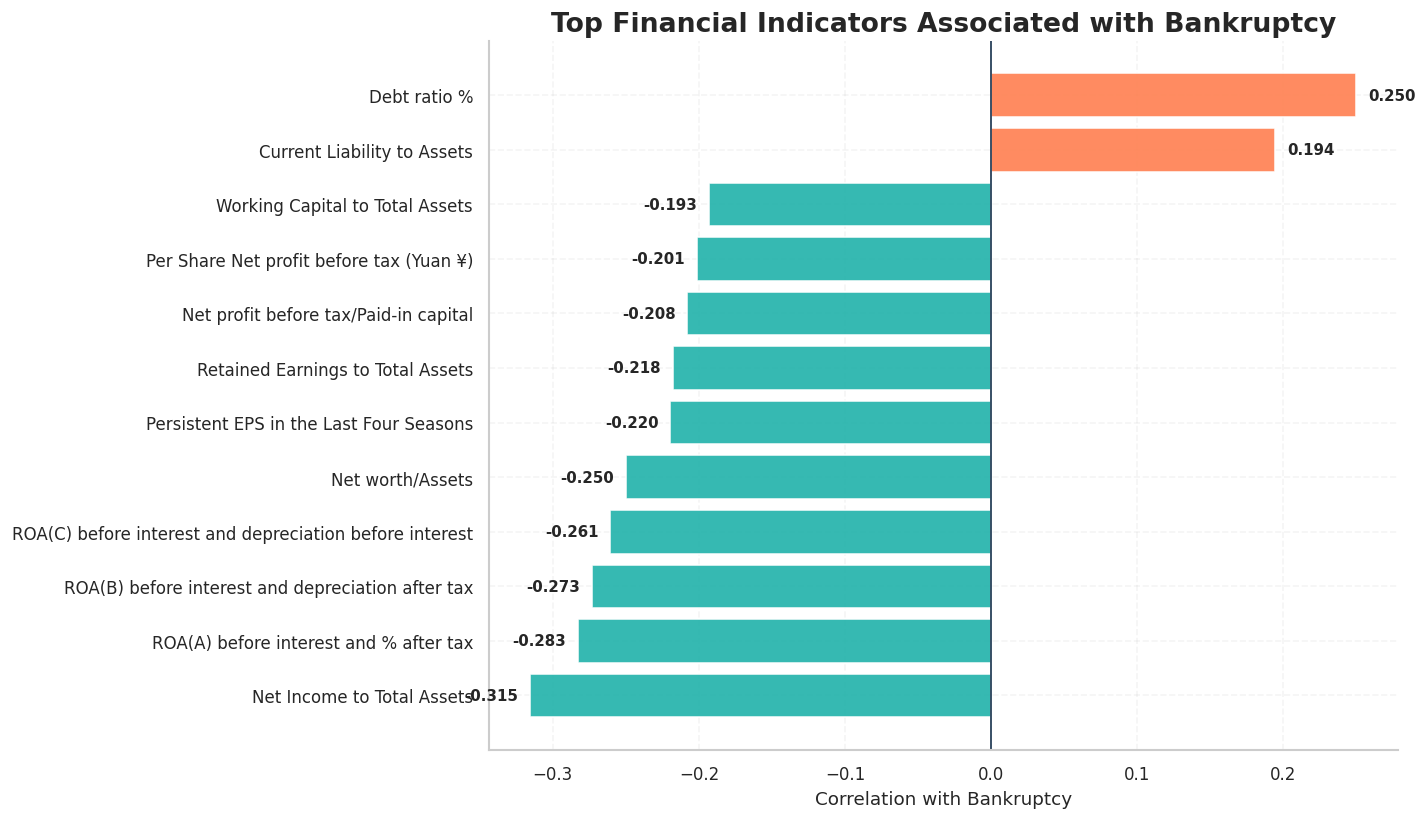

In [ ]:
# ── EDA 3.5: Top correlations with bankruptcy ──────────────────────────────

corr_to_target = (
    bankruptcy
    .corr(numeric_only=True)['Bankrupt?']
    .drop('Bankrupt?')
    .dropna()
)

top_corr_features = (
    corr_to_target
    .abs()
    .sort_values(ascending=False)
    .head(12)
    .index
)

top_correlations = corr_to_target.loc[top_corr_features].sort_values()

bar_colors = [
    FINANCE_COLORS['coral'] if value > 0
    else FINANCE_COLORS['teal']
    for value in top_correlations
]

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_correlations.index,
    top_correlations.values,
    color=bar_colors,
    alpha=0.90
)

plt.axvline(0, linewidth=1, color='#17324D')

plt.title(
    'Top Financial Indicators Associated with Bankruptcy',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Correlation with Bankruptcy')
plt.ylabel('')

for bar, value in zip(bars, top_correlations.values):

    offset = 0.008 if value >= 0 else -0.008

    plt.text(
        value + offset,
        bar.get_y() + bar.get_height()/2,
        f'{value:.3f}',
        va='center',
        ha='left' if value >= 0 else 'right',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### Insight

The correlation analysis highlights a clear contrast between profitability and financial leverage.

**Net Income to Total Assets** has the strongest negative association with bankruptcy, followed by several measures of Return on Assets. Higher profitability is therefore associated with lower bankruptcy risk.

In contrast, **Debt Ratio** and **Current Liability to Assets** show positive associations with bankruptcy, indicating that greater leverage and short-term liability pressure are associated with greater financial distress.

Correlation does not prove causation, but these relationships help identify potentially useful predictors for subsequent feature selection and modeling.
It is also important to note that no individual feature has an extremely strong correlation with bankruptcy; the largest absolute correlation is only around 0.32.

This suggests that bankruptcy risk is likely determined by the combined effect of multiple financial indicators rather than any single ratio.

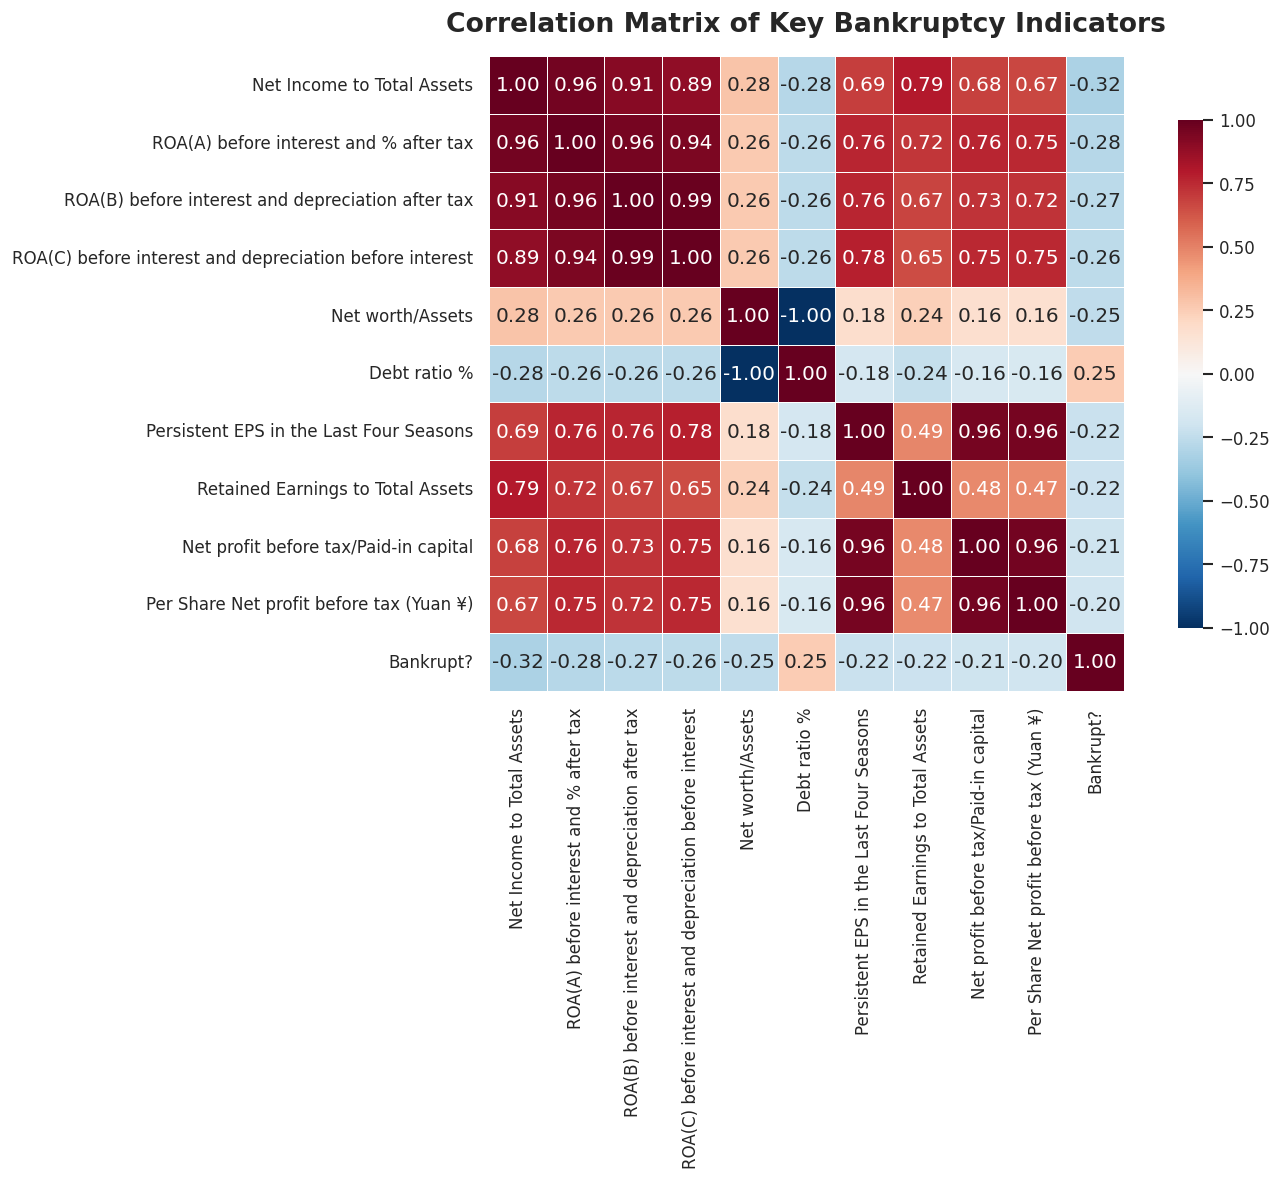

In [ ]:
# ── EDA 3.6: Focused correlation heatmap ───────────────────────────────────

top_10_features = (
    corr_to_target
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

heatmap_features = top_10_features + ['Bankrupt?']

focused_corr = bankruptcy[heatmap_features].corr()

plt.figure(figsize=(13, 10))

sns.heatmap(
    focused_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title(
    'Correlation Matrix of Key Bankruptcy Indicators',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()

### Insight

The focused correlation matrix shows that several profitability indicators are strongly related to one another, particularly different measures of Return on Assets.

This suggests that some predictors may contain overlapping information. Therefore, correlation and feature-selection methods will later be used to reduce redundancy before final model development.

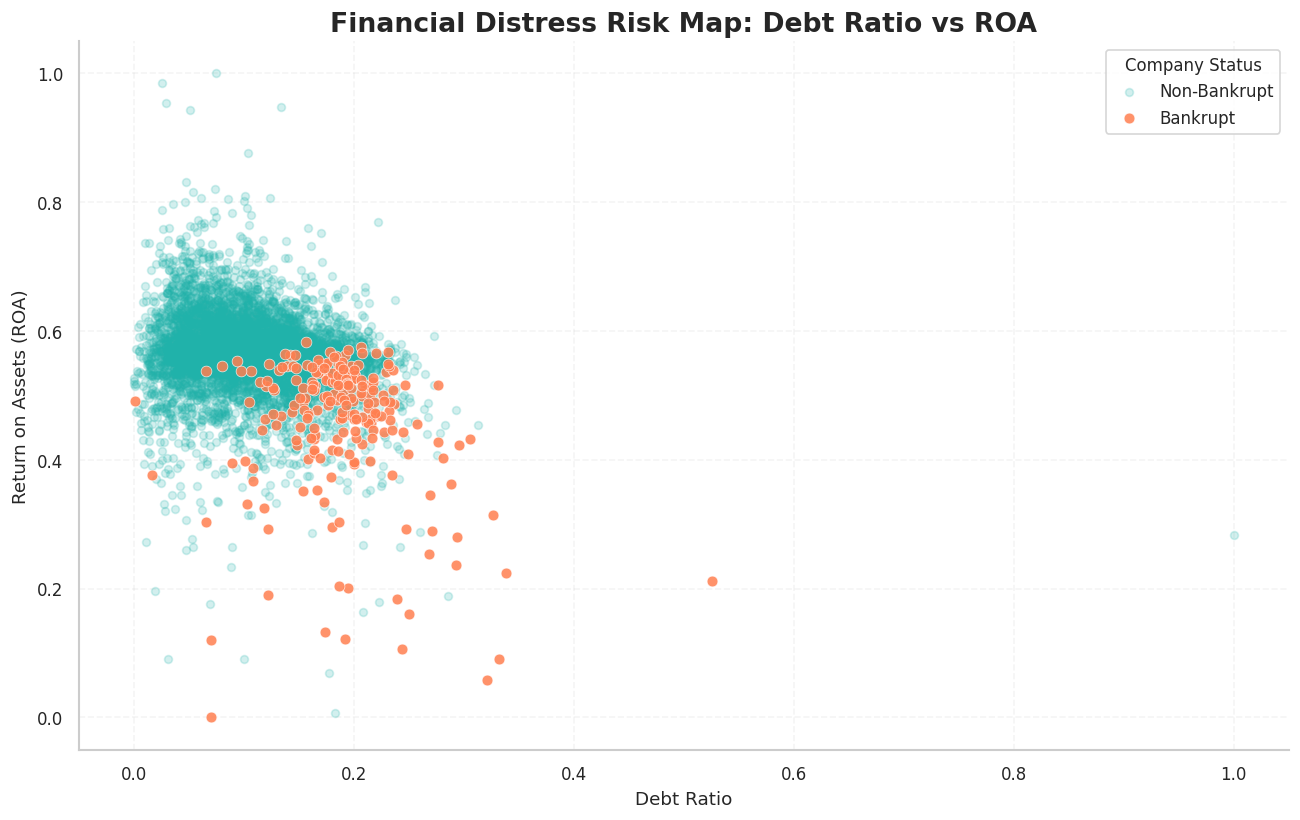

In [ ]:
# ── EDA 3.7: Profitability vs leverage risk map ────────────────────────────

non_bankrupt = eda_df[eda_df['Bankrupt?'] == 0]
bankrupt = eda_df[eda_df['Bankrupt?'] == 1]

plt.figure(figsize=(11, 7))

plt.scatter(
    non_bankrupt['Debt ratio %'],
    non_bankrupt['ROA(A) before interest and % after tax'],
    s=22,
    alpha=0.20,
    color=FINANCE_COLORS['teal'],
    label='Non-Bankrupt'
)

plt.scatter(
    bankrupt['Debt ratio %'],
    bankrupt['ROA(A) before interest and % after tax'],
    s=42,
    alpha=0.85,
    color=FINANCE_COLORS['coral'],
    edgecolors='white',
    linewidth=0.4,
    label='Bankrupt'
)

plt.title(
    'Financial Distress Risk Map: Debt Ratio vs ROA',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Debt Ratio')
plt.ylabel('Return on Assets (ROA)')
plt.legend(title='Company Status')

plt.tight_layout()
plt.show()

### Insight

The risk map combines two fundamental dimensions of corporate financial health: **leverage** and **profitability**.

Bankrupt firms are more concentrated in areas characterized by higher debt ratios and weaker return on assets. This illustrates how financial distress may emerge from the combination of excessive financial obligations and insufficient profitability.

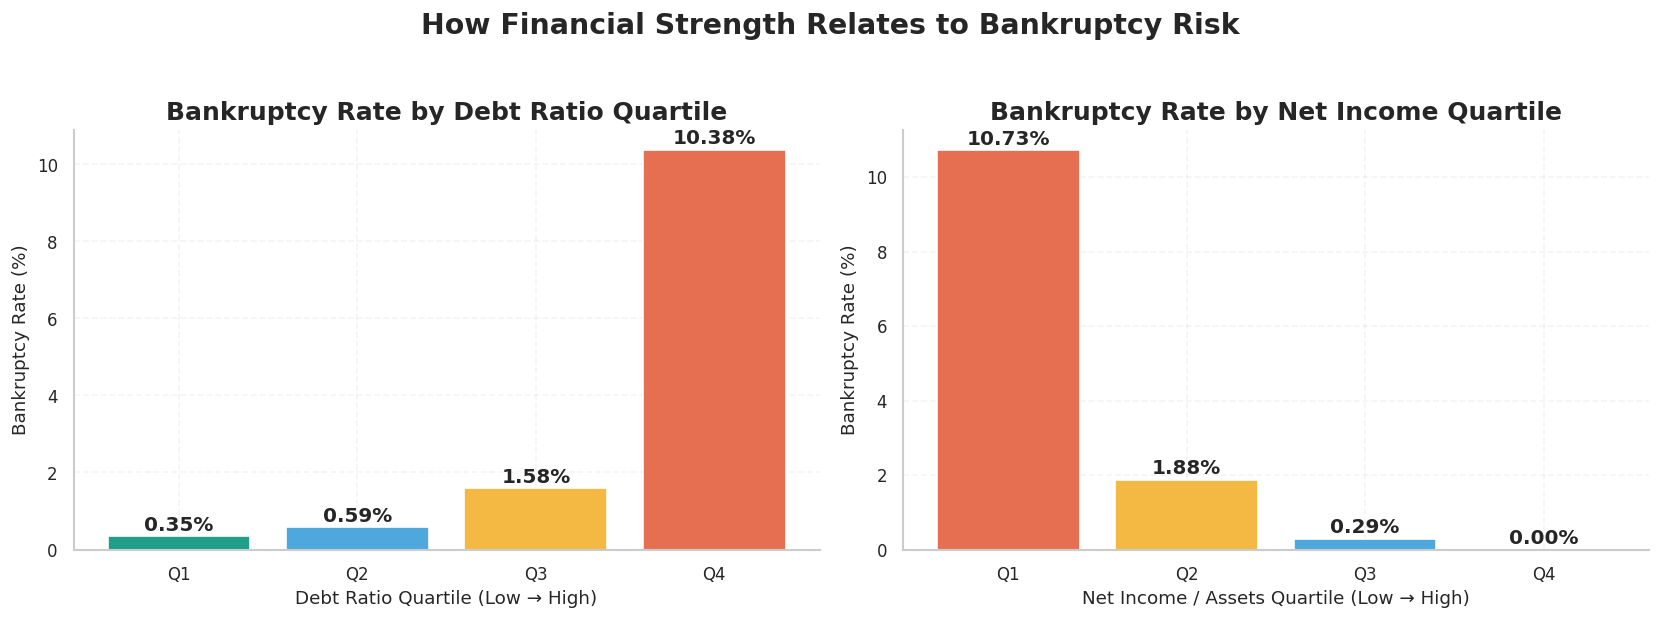

In [ ]:
# ── EDA 3.8: Bankruptcy rate across financial-risk quartiles ───────────────

quartile_labels = ['Q1', 'Q2', 'Q3', 'Q4']

# Debt ratio quartiles
debt_quartile = pd.qcut(
    bankruptcy['Debt ratio %'],
    q=4,
    labels=quartile_labels,
    duplicates='drop'
)

debt_risk = (
    bankruptcy
    .groupby(debt_quartile, observed=True)['Bankrupt?']
    .mean() * 100
)

# Net income quartiles
income_quartile = pd.qcut(
    bankruptcy['Net Income to Total Assets'],
    q=4,
    labels=quartile_labels,
    duplicates='drop'
)

income_risk = (
    bankruptcy
    .groupby(income_quartile, observed=True)['Bankrupt?']
    .mean() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Debt ratio
debt_colors = [
    '#1F9E89',  # Teal
    '#4EA8DE',  # Sky blue
    '#F4B942',  # Gold
    '#E76F51'   # Coral
]


bars1 = axes[0].bar(
    debt_risk.index,
    debt_risk.values,
    color=debt_colors
)

axes[0].set_title(
    'Bankruptcy Rate by Debt Ratio Quartile',
    fontweight='bold'
)
axes[0].set_xlabel('Debt Ratio Quartile (Low → High)')
axes[0].set_ylabel('Bankruptcy Rate (%)')

for bar, value in zip(bars1, debt_risk.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        value + 0.15,
        f'{value:.2f}%',
        ha='center',
        fontweight='bold'
    )

# Net Income ratio
income_colors = [
    '#E76F51',  # Coral
    '#F4B942',  # Gold
    '#4EA8DE',  # Sky blue
    '#1F9E89'   # Teal
]
bars2 = axes[1].bar(
    income_risk.index,
    income_risk.values,
    color=income_colors
)

axes[1].set_title(
    'Bankruptcy Rate by Net Income Quartile',
    fontweight='bold'
)
axes[1].set_xlabel('Net Income / Assets Quartile (Low → High)')
axes[1].set_ylabel('Bankruptcy Rate (%)')

for bar, value in zip(bars2, income_risk.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        value + 0.15,
        f'{value:.2f}%',
        ha='center',
        fontweight='bold'
    )

fig.suptitle(
    'How Financial Strength Relates to Bankruptcy Risk',
    fontsize=17,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

### Insight

The quartile analysis reveals a pronounced relationship between financial condition and bankruptcy.

Companies in the **highest debt-ratio quartile** exhibit a bankruptcy rate of approximately **10.38%**, compared with only about **0.35%** among companies in the lowest debt quartile.

Similarly, companies in the **lowest Net Income to Total Assets quartile** experience a bankruptcy rate of approximately **10.73%**, while bankruptcy is virtually absent among firms in the highest profitability quartile.

These results indicate that high leverage and weak profitability are useful candidate early-warning signals of corporate financial distress.

## EDA Summary

The exploratory analysis identifies several clear financial patterns associated with corporate bankruptcy:

**Profitability:** Bankrupt companies generally exhibit lower ROA, net income relative to assets, persistent earnings, and retained earnings.

**Financial leverage:** Bankrupt firms tend to carry higher debt ratios, liability-to-equity levels, and current liabilities relative to assets.

**Key predictor relationships:** Net Income to Total Assets and Return on Assets show some of the strongest negative associations with bankruptcy, while Debt Ratio and Current Liability to Assets show important positive associations.

**Financial distress pattern:** The combination of weak profitability and high leverage appears to characterize many bankrupt companies.

**Class imbalance:** Because bankrupt firms represent only 3.23% of the observations, subsequent modeling must emphasize Recall, Precision, F1-score, and ROC-AUC rather than relying only on Accuracy.

These findings provide a financial basis for the next stage of the project: **Feature Selection**.

# 4. Feature Selection

Feature selection identifies the financial indicators that contribute most strongly to bankruptcy prediction while reducing noise, redundancy, and unnecessary model complexity.

Because the dataset contains **94 predictor variables**, three steps are used:

1. **Pearson Correlation** — identifies financial indicators with the strongest linear association with bankruptcy.
2. **Random Forest Feature Importance** — captures non-linear relationships and interactions between financial indicators.
3. **Consensus Ranking and Redundancy Removal** — combines both methods and removes highly correlated predictors that provide overlapping information.

> Feature selection is performed using the **training data only** to prevent information from the test set from influencing model development.

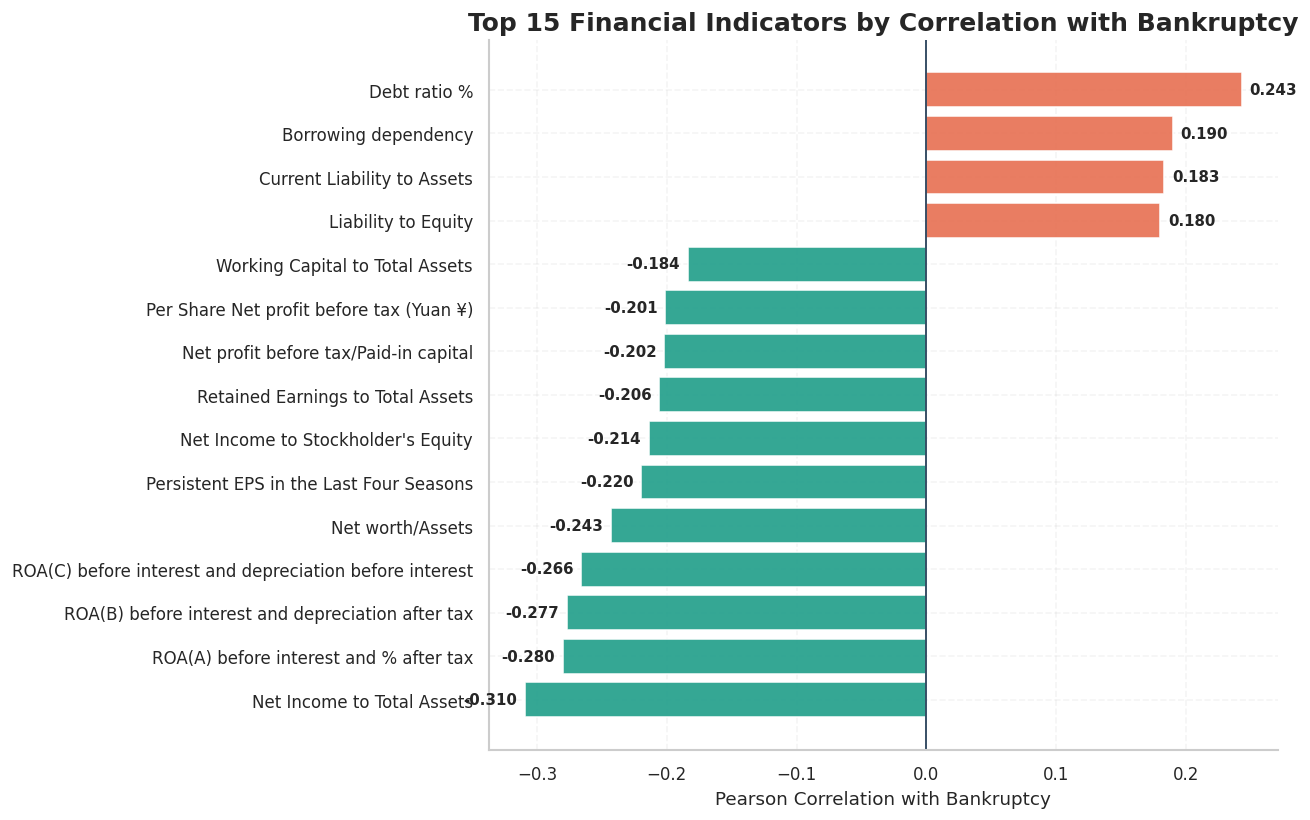

Top 15 features by absolute Pearson correlation:


,Correlation
Net Income to Total Assets,-0.3095
ROA(A) before interest and % after tax,-0.2800
ROA(B) before interest and depreciation after tax,-0.2773
ROA(C) before interest and depreciation before interest,-0.2658
Debt ratio %,0.2433
Net worth/Assets,-0.2433
Persistent EPS in the Last Four Seasons,-0.2196
Net Income to Stockholder's Equity,-0.2138
Retained Earnings to Total Assets,-0.2059
Net profit before tax/Paid-in capital,-0.2019


In [ ]:
# ── Feature Selection 4.1: Pearson Correlation with Bankruptcy ─────────────

train_fs = X_train_raw.copy()
train_fs['Bankrupt?'] = y_train

corr_with_target = (
    train_fs
    .corr(numeric_only=True)['Bankrupt?']
    .drop('Bankrupt?')
    .dropna()
)

top_corr = (
    corr_with_target
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

top_corr_signed = corr_with_target.loc[top_corr.index].sort_values()

# Fixed finance-theme colors
colors = [
    '#E76F51' if value > 0 else '#1F9E89'
    for value in top_corr_signed
]

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_corr_signed.index,
    top_corr_signed.values,
    color=colors,
    alpha=0.90
)

plt.axvline(0, color='#17324D', linewidth=1)

plt.title(
    'Top 15 Financial Indicators by Correlation with Bankruptcy',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Pearson Correlation with Bankruptcy')
plt.ylabel('')

for bar, value in zip(bars, top_corr_signed.values):
    plt.text(
        value + (0.006 if value >= 0 else -0.006),
        bar.get_y() + bar.get_height()/2,
        f'{value:.3f}',
        va='center',
        ha='left' if value >= 0 else 'right',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

print("Top 15 features by absolute Pearson correlation:")
display(
    corr_with_target.loc[top_corr.index]
    .sort_values(key=abs, ascending=False)
    .to_frame('Correlation')
    .round(4)
)

### Insight

Pearson correlation identifies several profitability and leverage indicators that are strongly associated with bankruptcy.

Negative correlations indicate that stronger profitability or financial strength is associated with lower bankruptcy risk, while positive correlations indicate that greater leverage or liability pressure is associated with higher bankruptcy risk.

However, correlation captures only linear relationships. Therefore, a tree-based method is also used to identify non-linear predictive relationships.

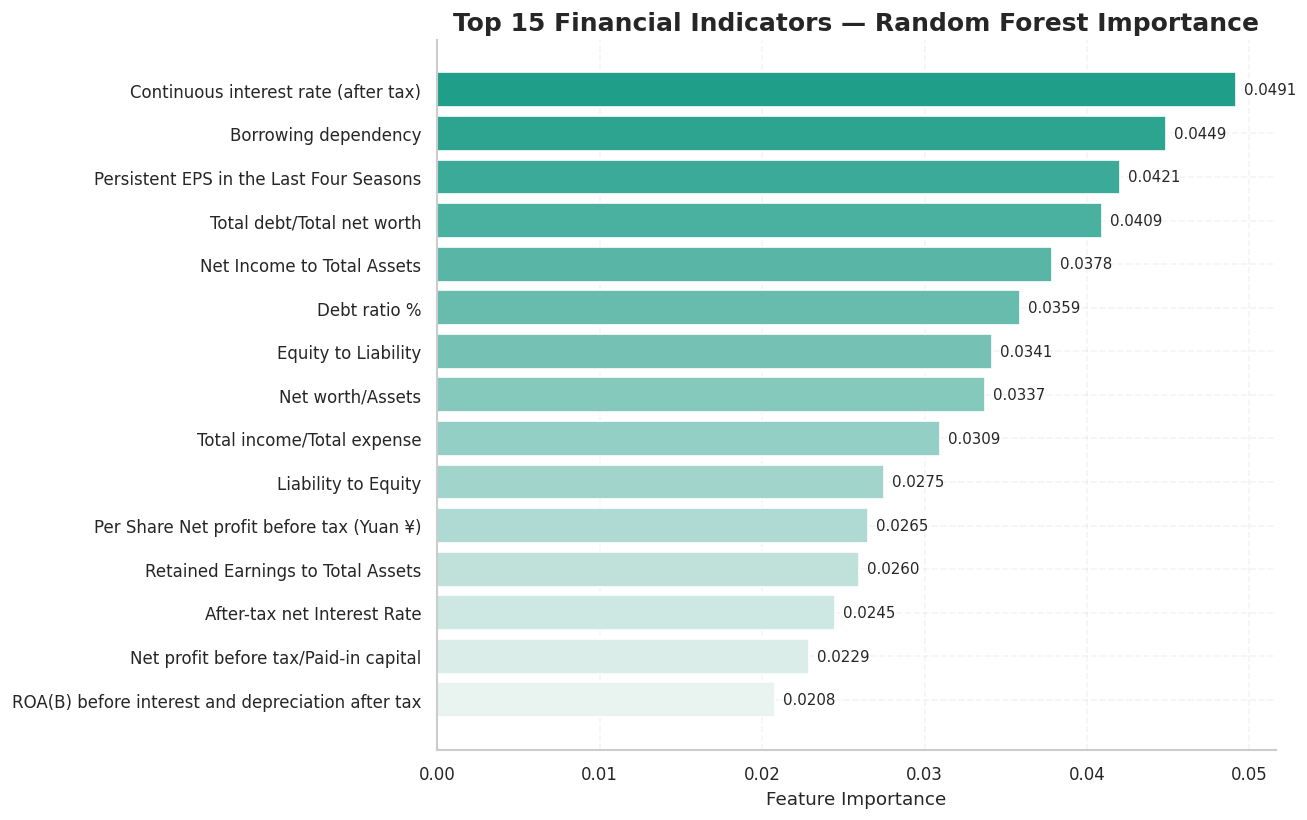

Top 15 Random Forest features:


,Importance
Continuous interest rate (after tax),0.0491
Borrowing dependency,0.0449
Persistent EPS in the Last Four Seasons,0.0421
Total debt/Total net worth,0.0409
Net Income to Total Assets,0.0378
Debt ratio %,0.0359
Equity to Liability,0.0341
Net worth/Assets,0.0337
Total income/Total expense,0.0309
Liability to Equity,0.0275


In [ ]:
# ── Feature Selection 4.2: Random Forest Feature Importance ────────────────

rf_selector = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# IMPORTANT: Training data only
rf_selector.fit(X_train_raw, y_train)

rf_importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_raw.columns
).sort_values(ascending=False)

top_rf = rf_importance.head(15)

# Professional teal gradient
rf_colors = sns.light_palette(
    '#1F9E89',
    n_colors=len(top_rf),
    reverse=True
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_rf.index[::-1],
    top_rf.values[::-1],
    color=rf_colors[::-1]
)

plt.title(
    'Top 15 Financial Indicators — Random Forest Importance',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Feature Importance')
plt.ylabel('')

for bar, value in zip(bars, top_rf.values[::-1]):
    plt.text(
        value + top_rf.max()*0.01,
        bar.get_y() + bar.get_height()/2,
        f'{value:.4f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("Top 15 Random Forest features:")
display(top_rf.to_frame('Importance').round(4))

### Insight

Random Forest importance provides a second perspective on feature relevance because it can capture non-linear relationships and interactions between financial indicators.

Features that rank highly in both Pearson correlation and Random Forest importance are especially strong candidates for the predictive models.

In [ ]:
# ── Feature Selection 4.3: Consensus ranking ───────────────────────────────

feature_ranking = pd.DataFrame({
    'Abs Pearson Correlation': corr_with_target.abs(),
    'Random Forest Importance': rf_importance
})

feature_ranking['Correlation Rank'] = (
    feature_ranking['Abs Pearson Correlation']
    .rank(ascending=False, method='min')
)

feature_ranking['RF Rank'] = (
    feature_ranking['Random Forest Importance']
    .rank(ascending=False, method='min')
)

feature_ranking['Average Rank'] = (
    feature_ranking['Correlation Rank'] +
    feature_ranking['RF Rank']
) / 2

feature_ranking = feature_ranking.sort_values('Average Rank')

top_20_candidates = feature_ranking.head(20)

print("=== TOP 20 FEATURES BY CONSENSUS RANKING ===")
display(top_20_candidates.round(4))

=== TOP 20 FEATURES BY CONSENSUS RANKING ===


,Abs Pearson Correlation,Random Forest Importance,Correlation Rank,RF Rank,Average Rank
Net Income to Total Assets,0.3095,0.0378,1.0,5.0,3.0
Persistent EPS in the Last Four Seasons,0.2196,0.0421,7.0,3.0,5.0
Debt ratio %,0.2433,0.0359,5.0,6.0,5.5
Net worth/Assets,0.2433,0.0337,6.0,8.0,7.0
Borrowing dependency,0.1902,0.0449,12.0,2.0,7.0
ROA(B) before interest and depreciation after tax,0.2773,0.0208,3.0,15.0,9.0
Retained Earnings to Total Assets,0.2059,0.0260,9.0,12.0,10.5
ROA(C) before interest and depreciation before interest,0.2658,0.0207,4.0,17.0,10.5
Per Share Net profit before tax (Yuan ¥),0.2012,0.0265,11.0,11.0,11.0
Net profit before tax/Paid-in capital,0.2019,0.0229,10.0,14.0,12.0


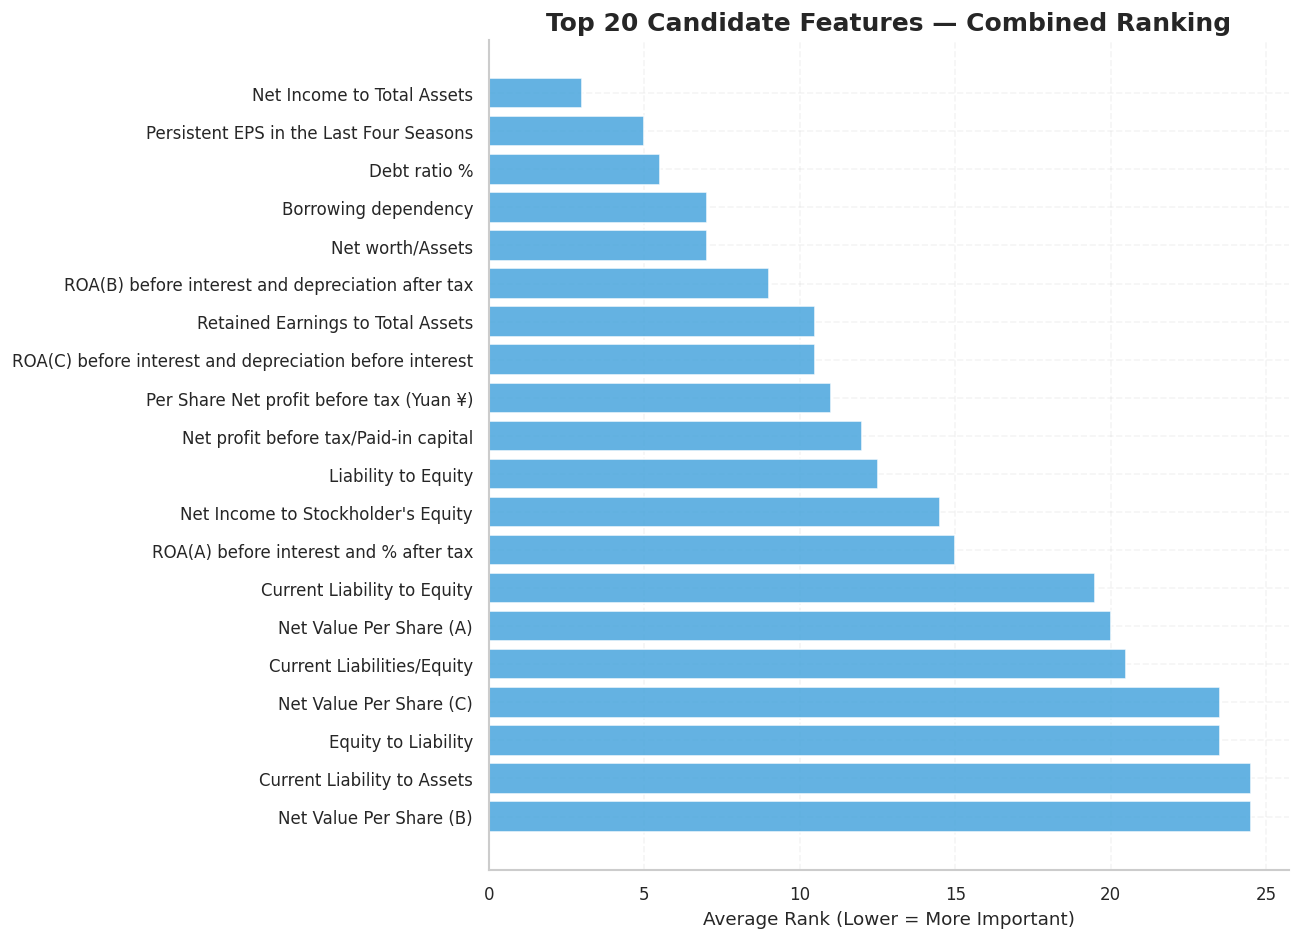

In [ ]:
# ── Feature Selection 4.4: Visualize consensus ranking ─────────────────────

plot_data = top_20_candidates.sort_values(
    'Average Rank',
    ascending=False
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    plot_data.index,
    plot_data['Average Rank'],
    color='#4EA8DE',
    alpha=0.88
)

plt.title(
    'Top 20 Candidate Features — Combined Ranking',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Average Rank (Lower = More Important)')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# ── Feature Selection 4.5: Remove highly redundant predictors ──────────────

candidate_features = top_20_candidates.index.tolist()

candidate_corr = (
    X_train_raw[candidate_features]
    .corr()
    .abs()
)

redundant_pairs = []

for i in range(len(candidate_features)):
    for j in range(i + 1, len(candidate_features)):

        feature_1 = candidate_features[i]
        feature_2 = candidate_features[j]

        correlation = candidate_corr.loc[feature_1, feature_2]

        if correlation > 0.90:
            redundant_pairs.append(
                [feature_1, feature_2, correlation]
            )

redundant_pairs_df = pd.DataFrame(
    redundant_pairs,
    columns=[
        'Feature 1',
        'Feature 2',
        'Absolute Correlation'
    ]
)

print("=== HIGHLY CORRELATED CANDIDATE FEATURES (> 0.90) ===")

if len(redundant_pairs_df) > 0:
    display(
        redundant_pairs_df
        .sort_values('Absolute Correlation', ascending=False)
        .round(4)
    )
else:
    print("✅ No highly redundant candidate features detected.")

=== HIGHLY CORRELATED CANDIDATE FEATURES (> 0.90) ===


,Feature 1,Feature 2,Absolute Correlation
12,Current Liability to Equity,Current Liabilities/Equity,1.0000
4,Debt ratio %,Net worth/Assets,1.0000
13,Net Value Per Share (A),Net Value Per Share (C),0.9999
14,Net Value Per Share (A),Net Value Per Share (B),0.9997
15,Net Value Per Share (C),Net Value Per Share (B),0.9996
6,ROA(B) before interest and depreciation after tax,ROA(C) before interest and depreciation before...,0.9867
9,Per Share Net profit before tax (Yuan ¥),Net profit before tax/Paid-in capital,0.9854
3,Persistent EPS in the Last Four Seasons,Net profit before tax/Paid-in capital,0.9806
2,Persistent EPS in the Last Four Seasons,Per Share Net profit before tax (Yuan ¥),0.9715
1,Net Income to Total Assets,ROA(A) before interest and % after tax,0.9608


In [ ]:
# ── Feature Selection 4.6: Final redundancy filtering ──────────────────────

final_features = candidate_features.copy()

for i in range(len(candidate_features)):

    for j in range(i + 1, len(candidate_features)):

        feature_1 = candidate_features[i]
        feature_2 = candidate_features[j]

        corr_value = candidate_corr.loc[
            feature_1,
            feature_2
        ]

        if (
            corr_value > 0.90 and
            feature_1 in final_features and
            feature_2 in final_features
        ):

            rank_1 = feature_ranking.loc[
                feature_1,
                'Average Rank'
            ]

            rank_2 = feature_ranking.loc[
                feature_2,
                'Average Rank'
            ]

            # Remove the weaker-ranked feature
            if rank_1 <= rank_2:
                final_features.remove(feature_2)
            else:
                final_features.remove(feature_1)

print("✅ Redundancy filtering completed.")

print(f"\nCandidate features : {len(candidate_features)}")
print(f"Final features     : {len(final_features)}")

print("\nFinal selected features:")

for number, feature in enumerate(final_features, start=1):
    print(f"{number:>2}. {feature}")

✅ Redundancy filtering completed.

Candidate features : 20
Final features     : 11

Final selected features:
 1. Net Income to Total Assets
 2. Persistent EPS in the Last Four Seasons
 3. Debt ratio %
 4. Borrowing dependency
 5. Retained Earnings to Total Assets
 6. ROA(C) before interest and depreciation before interest
 7. Net Income to Stockholder's Equity
 8. Current Liability to Equity
 9. Net Value Per Share (A)
10. Equity to Liability
11. Current Liability to Assets


In [ ]:
# ── Feature Selection 4.7: Apply selected features to existing split ───────

# Raw versions — for tree-based models
X_train_selected_raw = X_train_raw[final_features].copy()
X_test_selected_raw = X_test_raw[final_features].copy()

# Scaled versions — for Logistic Regression
X_train_selected = X_train[final_features].copy()
X_test_selected = X_test[final_features].copy()

print("✅ Feature selection applied to existing train/test split.")

print(f"\nSelected feature count : {len(final_features)}")

print(f"\nRaw training shape     : {X_train_selected_raw.shape}")
print(f"Raw testing shape      : {X_test_selected_raw.shape}")

print(f"Scaled training shape  : {X_train_selected.shape}")
print(f"Scaled testing shape   : {X_test_selected.shape}")

✅ Feature selection applied to existing train/test split.

Selected feature count : 11

Raw training shape     : (5114, 11)
Raw testing shape      : (1705, 11)
Scaled training shape  : (5114, 11)
Scaled testing shape   : (1705, 11)


## Feature Selection Summary

Feature selection was performed using the **training data only** to avoid test-set leakage.

Two complementary methods were applied:

- **Pearson Correlation** identified financial indicators with strong linear relationships with bankruptcy.
- **Random Forest Feature Importance** identified predictors with useful non-linear and interaction effects.

The two methods were combined through a consensus ranking. The top candidate predictors were then examined for multicollinearity, and highly correlated variables with an absolute correlation above **0.90** were filtered to reduce redundant information.

This approach reduces the original 94 predictors to 11 selected financial indicators while preserving the untouched test set for final model evaluation.

The selected features will now be used for **Model Building**.

# 5. Model Building

Four classification models are trained using the selected financial indicators and evaluated before hyperparameter optimization.

| # | Model | Why Chosen |
|---|---|---|
| 1 | Logistic Regression | Interpretable baseline model for binary financial-risk prediction |
| 2 | Decision Tree | Captures non-linear relationships and provides understandable decision rules |
| 3 | Random Forest | Ensemble model that reduces the instability and overfitting of a single tree |
| 4 | Support Vector Machine (SVM) | Effective for complex classification boundaries in scaled feature spaces |

### Evaluation Metrics

Because only **3.23%** of companies in the dataset are bankrupt, Accuracy alone may be misleading.

Therefore, the baseline models are compared using:

- **Accuracy** — overall proportion of correct predictions
- **Precision** — proportion of predicted bankrupt firms that are actually bankrupt
- **Recall** — proportion of actual bankrupt firms correctly identified
- **F1-score** — balance between Precision and Recall
- **ROC-AUC** — ability of the model to distinguish bankrupt from non-bankrupt companies

Greater emphasis is placed on **Recall, F1-score, and ROC-AUC** because failing to identify an actually distressed company can have significant financial consequences.

In [ ]:
# ── Additional classifier required for Model Building ──────────────────────

from sklearn.svm import SVC

print("✅ SVM classifier imported successfully.")

✅ SVM classifier imported successfully.


In [ ]:
# ── Model Building 5.1: Classification evaluation helper ──────────────────

def evaluate_classifier(model_name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred) * 100
    precision = precision_score(y_true, y_pred, zero_division=0) * 100
    recall = recall_score(y_true, y_pred, zero_division=0) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    roc_auc = roc_auc_score(y_true, y_prob) * 100

    print("\n" + "=" * 55)
    print(model_name)
    print("=" * 55)

    print(f"Accuracy  : {accuracy:.2f}%")
    print(f"Precision : {precision:.2f}%")
    print(f"Recall    : {recall:.2f}%")
    print(f"F1-score  : {f1:.2f}%")
    print(f"ROC-AUC   : {roc_auc:.2f}%")

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    }


results_before = []

print("✅ Classification evaluation function ready.")

✅ Classification evaluation function ready.


In [ ]:
# ── Model 5.2: Logistic Regression ─────────────────────────────────────────

log_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(
    X_train_selected,
    y_train
)

# Predictions
y_pred_log = log_model.predict(X_test_selected)

# Probability of bankruptcy
y_prob_log = log_model.predict_proba(X_test_selected)[:, 1]

# Evaluation
res_log = evaluate_classifier(
    'Logistic Regression',
    y_test,
    y_pred_log,
    y_prob_log
)

results_before.append(res_log)

print(
    f"\nTrain Accuracy: "
    f"{log_model.score(X_train_selected, y_train)*100:.2f}%"
)

print(
    f"Test Accuracy : "
    f"{log_model.score(X_test_selected, y_test)*100:.2f}%"
)


Logistic Regression
Accuracy  : 87.51%
Precision : 17.89%
Recall    : 80.00%
F1-score  : 29.24%
ROC-AUC   : 90.56%

Train Accuracy: 86.43%
Test Accuracy : 87.51%


### Logistic Regression

Logistic Regression serves as an interpretable baseline for bankruptcy prediction.

`class_weight='balanced'` is used because bankrupt companies are substantially less common than non-bankrupt companies. This gives greater importance to the minority bankruptcy class during training.

The model uses the scaled selected features because Logistic Regression is sensitive to differences in feature scale.

In [ ]:
# ── Model 5.3: Decision Tree Classifier ────────────────────────────────────

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(
    X_train_selected_raw,
    y_train
)

y_pred_dt = dt_model.predict(X_test_selected_raw)

y_prob_dt = dt_model.predict_proba(
    X_test_selected_raw
)[:, 1]

res_dt = evaluate_classifier(
    'Decision Tree',
    y_test,
    y_pred_dt,
    y_prob_dt
)

results_before.append(res_dt)

train_acc_dt = (
    dt_model.score(X_train_selected_raw, y_train) * 100
)

test_acc_dt = (
    dt_model.score(X_test_selected_raw, y_test) * 100
)

print(f"\nTrain Accuracy: {train_acc_dt:.2f}%")
print(f"Test Accuracy : {test_acc_dt:.2f}%")

if train_acc_dt - test_acc_dt > 5:
    print(
        "\n⚠️ The gap between training and testing performance "
        "suggests possible overfitting."
    )
    print(
        "This will be addressed through hyperparameter "
        "optimization in Section 6."
    )


Decision Tree
Accuracy  : 94.90%
Precision : 22.41%
Recall    : 23.64%
F1-score  : 23.01%
ROC-AUC   : 60.45%

Train Accuracy: 100.00%
Test Accuracy : 94.90%

⚠️ The gap between training and testing performance suggests possible overfitting.
This will be addressed through hyperparameter optimization in Section 6.


### Decision Tree

The Decision Tree can identify non-linear relationships between financial indicators and bankruptcy.

Unlike Logistic Regression, tree-based models do not require standardized predictors.

An unrestricted Decision Tree may fit the training data too closely. Therefore, any evidence of overfitting will be addressed during **Model Optimization** using parameters such as maximum tree depth and minimum samples per split.

In [ ]:
# ── Model 5.4: Random Forest Classifier ────────────────────────────────────

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(
    X_train_selected_raw,
    y_train
)

y_pred_rf = rf_model.predict(X_test_selected_raw)

y_prob_rf = rf_model.predict_proba(
    X_test_selected_raw
)[:, 1]

res_rf = evaluate_classifier(
    'Random Forest',
    y_test,
    y_pred_rf,
    y_prob_rf
)

results_before.append(res_rf)

print(
    f"\nTrain Accuracy: "
    f"{rf_model.score(X_train_selected_raw, y_train)*100:.2f}%"
)

print(
    f"Test Accuracy : "
    f"{rf_model.score(X_test_selected_raw, y_test)*100:.2f}%"
)


Random Forest
Accuracy  : 96.83%
Precision : 57.14%
Recall    : 7.27%
F1-score  : 12.90%
ROC-AUC   : 90.83%

Train Accuracy: 100.00%
Test Accuracy : 96.83%


### Random Forest

Random Forest combines predictions from many Decision Trees rather than relying on a single tree.

This generally improves stability and reduces the overfitting associated with an unrestricted Decision Tree. It is also capable of identifying complex and non-linear relationships among financial indicators.

Class weighting is again used to account for the small number of bankrupt companies.

In [ ]:
# ── Model 5.5: Support Vector Machine (SVM) ────────────────────────────────

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(
    X_train_selected,
    y_train
)

y_pred_svm = svm_model.predict(X_test_selected)

y_prob_svm = svm_model.predict_proba(
    X_test_selected
)[:, 1]

res_svm = evaluate_classifier(
    'Support Vector Machine',
    y_test,
    y_pred_svm,
    y_prob_svm
)

results_before.append(res_svm)

print(
    f"\nTrain Accuracy: "
    f"{svm_model.score(X_train_selected, y_train)*100:.2f}%"
)

print(
    f"Test Accuracy : "
    f"{svm_model.score(X_test_selected, y_test)*100:.2f}%"
)


Support Vector Machine
Accuracy  : 86.63%
Precision : 14.40%
Recall    : 63.64%
F1-score  : 23.49%
ROC-AUC   : 88.60%

Train Accuracy: 86.25%
Test Accuracy : 86.63%


### Support Vector Machine

The Support Vector Machine uses an RBF kernel to capture complex, non-linear classification boundaries.

Because SVM is sensitive to feature magnitude, the standardized selected features are used.

Class weighting is applied to give greater consideration to the minority bankruptcy class.

In [ ]:
# ── Model Building 5.6: Baseline model comparison ──────────────────────────

results_before_df = pd.DataFrame(results_before)

results_before_df = (
    results_before_df
    .sort_values(
        by='F1-score',
        ascending=False
    )
    .reset_index(drop=True)
)

print("=== MODEL COMPARISON — BEFORE OPTIMIZATION ===")

display(
    results_before_df.style.format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-score': '{:.2f}%',
        'ROC-AUC': '{:.2f}%'
    })
)

=== MODEL COMPARISON — BEFORE OPTIMIZATION ===


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,87.51%,17.89%,80.00%,29.24%,90.56%
1,Support Vector Machine,86.63%,14.40%,63.64%,23.49%,88.60%
2,Decision Tree,94.90%,22.41%,23.64%,23.01%,60.45%
3,Random Forest,96.83%,57.14%,7.27%,12.90%,90.83%


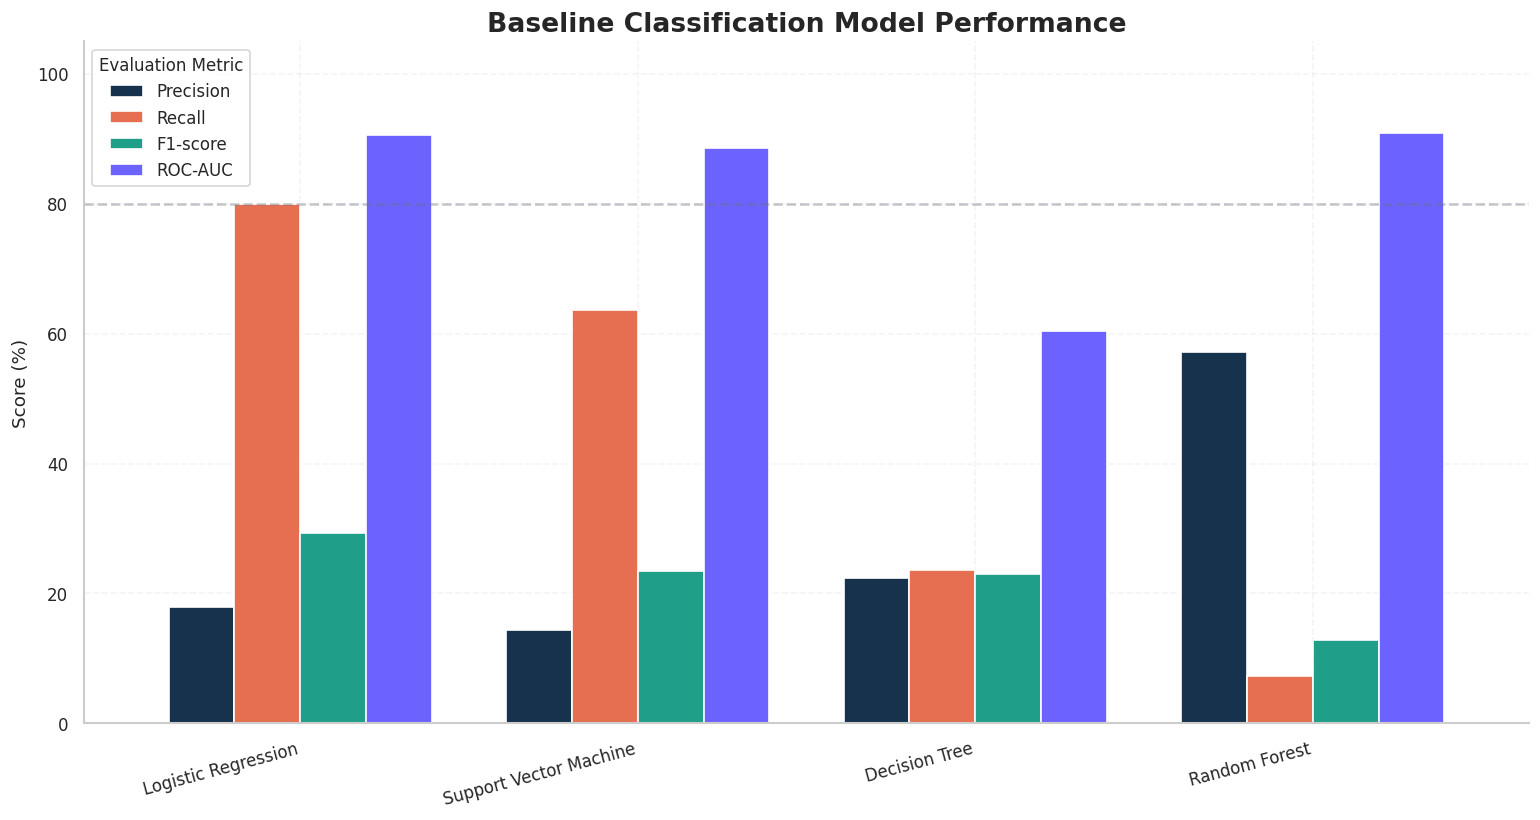

In [ ]:
# ── Model Building 5.7: Visual comparison of baseline models ───────────────

comparison_plot = (
    results_before_df
    .set_index('Model')[
        ['Precision', 'Recall', 'F1-score', 'ROC-AUC']
    ]
)

ax = comparison_plot.plot(
    kind='bar',
    figsize=(13, 7),
    width=0.78,
    color=[
        '#17324D',   # Navy
        '#E76F51',   # Coral
        '#1F9E89',   # Teal
        '#6C63FF'    # Purple
    ]
)

plt.title(
    'Baseline Classification Model Performance',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('Score (%)')

plt.ylim(0, 105)

plt.xticks(
    rotation=15,
    ha='right'
)

plt.legend(
    title='Evaluation Metric',
    frameon=True
)

plt.axhline(
    80,
    color='#6B7280',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [ ]:
# ── Model Building 5.8: Identify strongest baseline candidates ─────────────

best_f1 = results_before_df.loc[
    results_before_df['F1-score'].idxmax()
]

best_auc = results_before_df.loc[
    results_before_df['ROC-AUC'].idxmax()
]

best_recall = results_before_df.loc[
    results_before_df['Recall'].idxmax()
]

print("=== STRONGEST BASELINE MODELS ===")

print(
    f"\nHighest F1-score : "
    f"{best_f1['Model']} "
    f"({best_f1['F1-score']:.2f}%)"
)

print(
    f"Highest ROC-AUC  : "
    f"{best_auc['Model']} "
    f"({best_auc['ROC-AUC']:.2f}%)"
)

print(
    f"Highest Recall   : "
    f"{best_recall['Model']} "
    f"({best_recall['Recall']:.2f}%)"
)

=== STRONGEST BASELINE MODELS ===

Highest F1-score : Logistic Regression (29.24%)
Highest ROC-AUC  : Random Forest (90.83%)
Highest Recall   : Logistic Regression (80.00%)


## Model Building Summary

Four classification algorithms were evaluated using the selected financial indicators before hyperparameter optimization.

The models represent different predictive approaches:

- **Logistic Regression** provides an interpretable statistical baseline.
- **Decision Tree** captures non-linear decision relationships.
- **Random Forest** uses an ensemble of trees to improve robustness.
- **Support Vector Machine** captures complex classification boundaries.

Because the bankruptcy dataset is highly imbalanced, model quality is not determined by Accuracy alone. Particular attention is given to **Recall, F1-score, and ROC-AUC**.

These baseline results provide the reference point for the next stage, **Model Optimization**, where hyperparameters will be systematically tuned using cross-validation.

Baseline test results are reported for comparison only. Hyperparameter selection in the optimization stage will be performed using cross-validation on the training data rather than repeatedly using the test set.

# 6. Model Optimization

Model optimization improves predictive performance by tuning **hyperparameters**, which are model settings specified before training.

Because the bankruptcy dataset is highly imbalanced, optimization is performed using **Stratified 5-Fold Cross-Validation** on the training data only.

### Optimization Method

- **GridSearchCV** tests multiple hyperparameter combinations systematically.
- **Stratified 5-Fold Cross-Validation** preserves the bankruptcy class proportion across validation folds.
- **F1-score** is used as the primary optimization metric because it balances Precision and Recall.

The following baseline models are optimized:

1. **Logistic Regression**
2. **Random Forest**
3. **Support Vector Machine (SVM)**

> The test dataset is not used to choose hyperparameters. It is reserved for final evaluation.

In [ ]:
# ── Optimization 6.1: Cross-validation strategy ────────────────────────────

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("✅ Stratified 5-Fold Cross-Validation configured.")

✅ Stratified 5-Fold Cross-Validation configured.


In [ ]:
# ── Optimization 6.2: Logistic Regression — GridSearchCV ──────────────────

print("🔍 Optimizing Logistic Regression...")

log_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': ['balanced']
}

log_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    param_grid=log_param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

log_grid.fit(X_train_selected, y_train)

log_best = log_grid.best_estimator_

print("\n✅ Best Parameters:")
print(log_grid.best_params_)

print(
    f"\nBest Cross-Validated F1-score: "
    f"{log_grid.best_score_*100:.2f}%"
)

🔍 Optimizing Logistic Regression...

✅ Best Parameters:
{'C': 100, 'class_weight': 'balanced', 'solver': 'liblinear'}

Best Cross-Validated F1-score: 28.65%


In [ ]:
# ── Optimization 6.3: Random Forest — GridSearchCV ────────────────────────

print("🔍 Optimizing Random Forest...")

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_selected_raw, y_train)

rf_best = rf_grid.best_estimator_

print("\n✅ Best Parameters:")
print(rf_grid.best_params_)

print(
    f"\nBest Cross-Validated F1-score: "
    f"{rf_grid.best_score_*100:.2f}%"
)

🔍 Optimizing Random Forest...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits

✅ Best Parameters:
{'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

Best Cross-Validated F1-score: 41.67%


In [ ]:
# ── Optimization 6.4: SVM — GridSearchCV ──────────────────────────────────

print("🔍 Optimizing Support Vector Machine...")

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

svm_grid = GridSearchCV(
    estimator=SVC(
        probability=True,
        random_state=42
    ),
    param_grid=svm_param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_selected, y_train)

svm_best = svm_grid.best_estimator_

print("\n✅ Best Parameters:")
print(svm_grid.best_params_)

print(
    f"\nBest Cross-Validated F1-score: "
    f"{svm_grid.best_score_*100:.2f}%"
)

🔍 Optimizing Support Vector Machine...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross-Validated F1-score: 27.30%


In [ ]:
# ── Optimization 6.5: Evaluate optimized models ────────────────────────────

optimized_results = []

# Logistic Regression
y_pred_log_opt = log_best.predict(X_test_selected)
y_prob_log_opt = log_best.predict_proba(X_test_selected)[:, 1]

optimized_results.append(
    evaluate_classifier(
        'Logistic Regression (Optimized)',
        y_test,
        y_pred_log_opt,
        y_prob_log_opt
    )
)

# Random Forest
y_pred_rf_opt = rf_best.predict(X_test_selected_raw)
y_prob_rf_opt = rf_best.predict_proba(X_test_selected_raw)[:, 1]

optimized_results.append(
    evaluate_classifier(
        'Random Forest (Optimized)',
        y_test,
        y_pred_rf_opt,
        y_prob_rf_opt
    )
)

# SVM
y_pred_svm_opt = svm_best.predict(X_test_selected)
y_prob_svm_opt = svm_best.predict_proba(X_test_selected)[:, 1]

optimized_results.append(
    evaluate_classifier(
        'SVM (Optimized)',
        y_test,
        y_pred_svm_opt,
        y_prob_svm_opt
    )
)

optimized_results_df = pd.DataFrame(optimized_results)

print("\n=== OPTIMIZED MODEL COMPARISON ===")

display(
    optimized_results_df.style.format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-score': '{:.2f}%',
        'ROC-AUC': '{:.2f}%'
    })
)


Logistic Regression (Optimized)
Accuracy  : 87.33%
Precision : 17.67%
Recall    : 80.00%
F1-score  : 28.95%
ROC-AUC   : 90.20%

Random Forest (Optimized)
Accuracy  : 95.19%
Precision : 36.36%
Recall    : 65.45%
F1-score  : 46.75%
ROC-AUC   : 92.06%

SVM (Optimized)
Accuracy  : 86.63%
Precision : 14.40%
Recall    : 63.64%
F1-score  : 23.49%
ROC-AUC   : 88.60%

=== OPTIMIZED MODEL COMPARISON ===


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression (Optimized),87.33%,17.67%,80.00%,28.95%,90.20%
1,Random Forest (Optimized),95.19%,36.36%,65.45%,46.75%,92.06%
2,SVM (Optimized),86.63%,14.40%,63.64%,23.49%,88.60%


In [ ]:
# ── Optimization 6.6: Before vs After comparison ───────────────────────────

baseline_selected = results_before_df[
    results_before_df['Model'].isin([
        'Logistic Regression',
        'Random Forest',
        'Support Vector Machine'
    ])
].copy()

baseline_selected['Stage'] = 'Before Optimization'

optimized_compare = optimized_results_df.copy()

optimized_compare['Model'] = (
    optimized_compare['Model']
    .str.replace(' (Optimized)', '', regex=False)
    .replace({'SVM': 'Support Vector Machine'})
)

optimized_compare['Stage'] = 'After Optimization'

optimization_comparison = pd.concat(
    [baseline_selected, optimized_compare],
    ignore_index=True
)

print("=== BEFORE VS AFTER OPTIMIZATION ===")

display(
    optimization_comparison[
        [
            'Model',
            'Stage',
            'Accuracy',
            'Precision',
            'Recall',
            'F1-score',
            'ROC-AUC'
        ]
    ].style.format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-score': '{:.2f}%',
        'ROC-AUC': '{:.2f}%'
    })
)

=== BEFORE VS AFTER OPTIMIZATION ===


,Model,Stage,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,Before Optimization,87.51%,17.89%,80.00%,29.24%,90.56%
1,Support Vector Machine,Before Optimization,86.63%,14.40%,63.64%,23.49%,88.60%
2,Random Forest,Before Optimization,96.83%,57.14%,7.27%,12.90%,90.83%
3,Logistic Regression,After Optimization,87.33%,17.67%,80.00%,28.95%,90.20%
4,Random Forest,After Optimization,95.19%,36.36%,65.45%,46.75%,92.06%
5,Support Vector Machine,After Optimization,86.63%,14.40%,63.64%,23.49%,88.60%


## Model Optimization Summary

Three baseline classifiers were optimized using **GridSearchCV with Stratified 5-Fold Cross-Validation**.

Hyperparameter selection was performed entirely on the training data, with **F1-score** used as the primary optimization criterion because the bankruptcy class is highly imbalanced.

The optimized models are compared with their baseline versions to determine whether tuning improves the balance between detecting bankrupt companies and avoiding excessive false alarms.

The final optimized models will now undergo detailed **Model Evaluation & Validation**, including confusion matrices, ROC curves, cross-validation stability, and final model selection.

# 7. Model Evaluation & Validation

The final models are evaluated using the untouched test dataset and cross-validation results.

Because bankruptcy represents only **3.23%** of observations, model performance is assessed using multiple classification metrics rather than Accuracy alone.

| Metric | Meaning | Preferred Direction |
|---|---|---|
| Accuracy | Overall proportion of correct predictions | Higher |
| Precision | How many predicted bankrupt firms were actually bankrupt | Higher |
| Recall | How many actual bankrupt firms were correctly detected | Higher |
| F1-score | Balance between Precision and Recall | Higher |
| ROC-AUC | Ability to distinguish bankrupt from non-bankrupt companies | Higher |

Particular attention is given to **Recall and F1-score**, because failing to detect a financially distressed company may be more costly than generating some additional false alarms.

In [ ]:
# ── Evaluation 7.1: Final model comparison ─────────────────────────────────

final_results = []

# Optimized Logistic Regression
final_results.append(
    evaluate_classifier(
        'Logistic Regression (Optimized)',
        y_test,
        y_pred_log_opt,
        y_prob_log_opt
    )
)

# Decision Tree baseline
final_results.append(
    evaluate_classifier(
        'Decision Tree',
        y_test,
        y_pred_dt,
        y_prob_dt
    )
)

# Optimized Random Forest
final_results.append(
    evaluate_classifier(
        'Random Forest (Optimized)',
        y_test,
        y_pred_rf_opt,
        y_prob_rf_opt
    )
)

# Optimized SVM
final_results.append(
    evaluate_classifier(
        'SVM (Optimized)',
        y_test,
        y_pred_svm_opt,
        y_prob_svm_opt
    )
)

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by='F1-score',
    ascending=False
).reset_index(drop=True)

print("=== FINAL MODEL EVALUATION RESULTS ===")

display(
    final_results_df.style.format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-score': '{:.2f}%',
        'ROC-AUC': '{:.2f}%'
    })
)


Logistic Regression (Optimized)
Accuracy  : 87.33%
Precision : 17.67%
Recall    : 80.00%
F1-score  : 28.95%
ROC-AUC   : 90.20%

Decision Tree
Accuracy  : 94.90%
Precision : 22.41%
Recall    : 23.64%
F1-score  : 23.01%
ROC-AUC   : 60.45%

Random Forest (Optimized)
Accuracy  : 95.19%
Precision : 36.36%
Recall    : 65.45%
F1-score  : 46.75%
ROC-AUC   : 92.06%

SVM (Optimized)
Accuracy  : 86.63%
Precision : 14.40%
Recall    : 63.64%
F1-score  : 23.49%
ROC-AUC   : 88.60%
=== FINAL MODEL EVALUATION RESULTS ===


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest (Optimized),95.19%,36.36%,65.45%,46.75%,92.06%
1,Logistic Regression (Optimized),87.33%,17.67%,80.00%,28.95%,90.20%
2,SVM (Optimized),86.63%,14.40%,63.64%,23.49%,88.60%
3,Decision Tree,94.90%,22.41%,23.64%,23.01%,60.45%


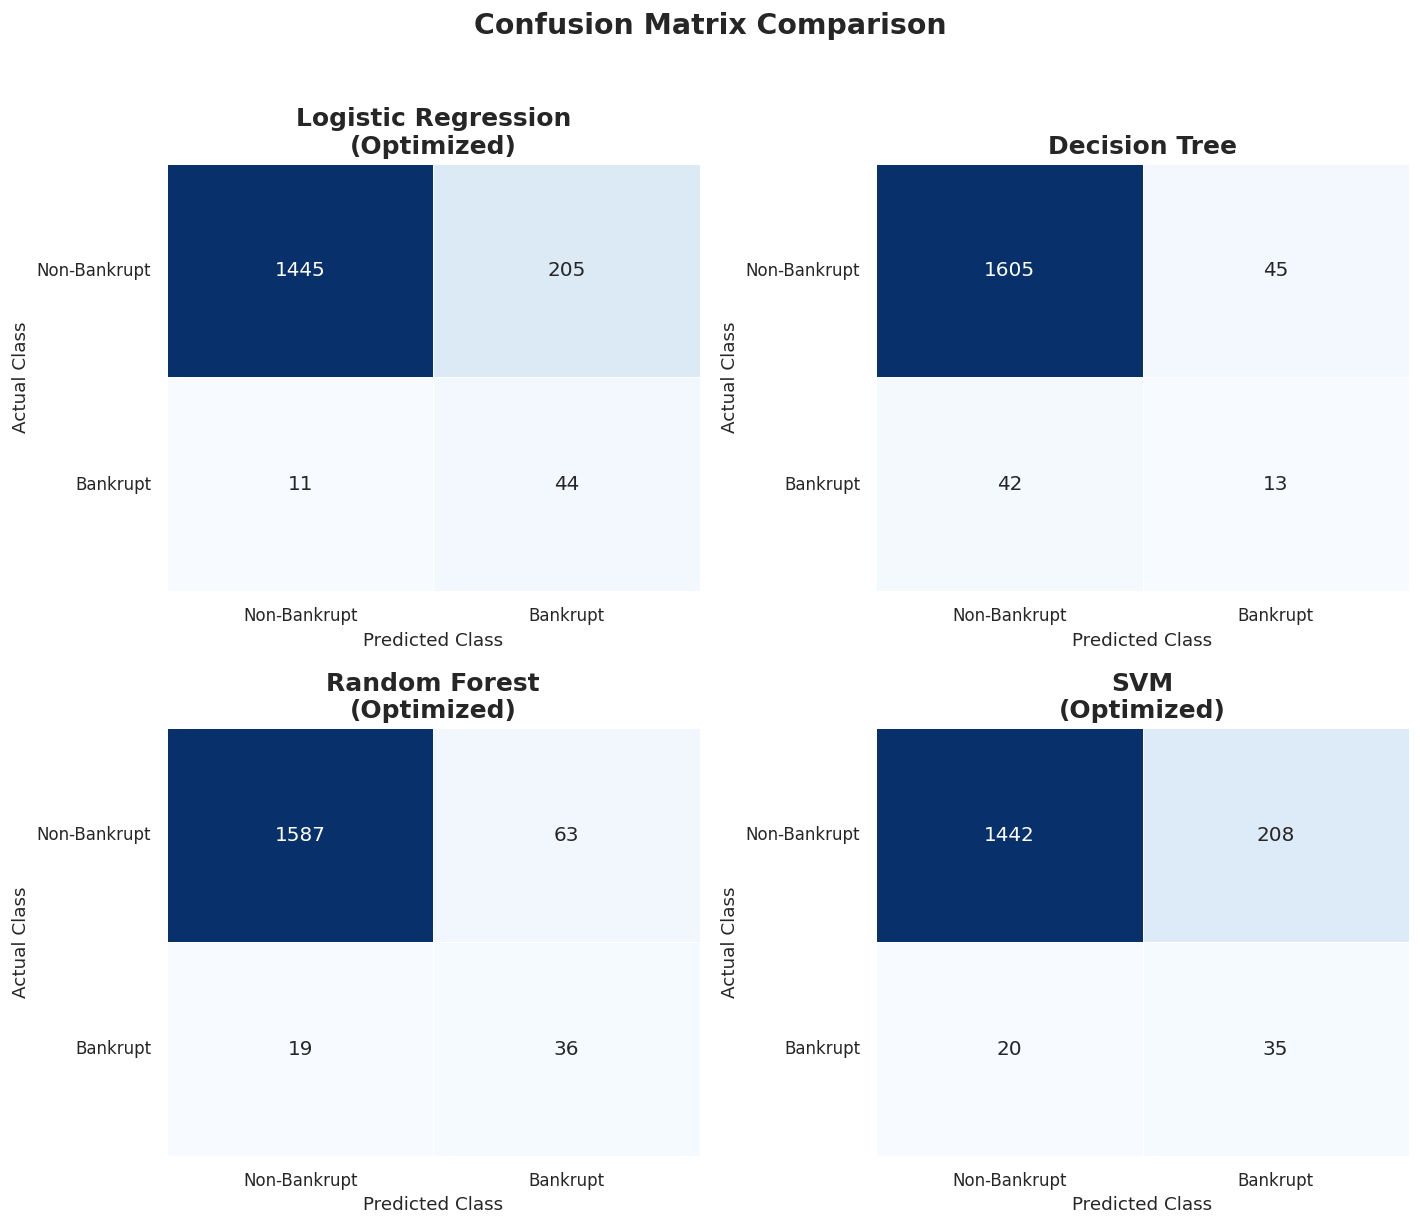

In [ ]:
# ── Evaluation 7.2: Confusion matrices ─────────────────────────────────────

models_cm = {
    'Logistic Regression\n(Optimized)': y_pred_log_opt,
    'Decision Tree': y_pred_dt,
    'Random Forest\n(Optimized)': y_pred_rf_opt,
    'SVM\n(Optimized)': y_pred_svm_opt
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, predictions) in zip(axes, models_cm.items()):

    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        linewidths=0.5
    )

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('Actual Class')

    ax.set_xticklabels(
        ['Non-Bankrupt', 'Bankrupt']
    )

    ax.set_yticklabels(
        ['Non-Bankrupt', 'Bankrupt'],
        rotation=0
    )

fig.suptitle(
    'Confusion Matrix Comparison',
    fontsize=17,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Confusion Matrix Insight

The confusion matrices show not only how many companies are classified correctly, but also the type of classification errors made by each model.

For this project, **False Negatives are particularly important**. A False Negative occurs when a company is actually bankrupt but the model predicts it as non-bankrupt.

A financial early-warning system should therefore aim to reduce False Negatives while maintaining a reasonable level of Precision.

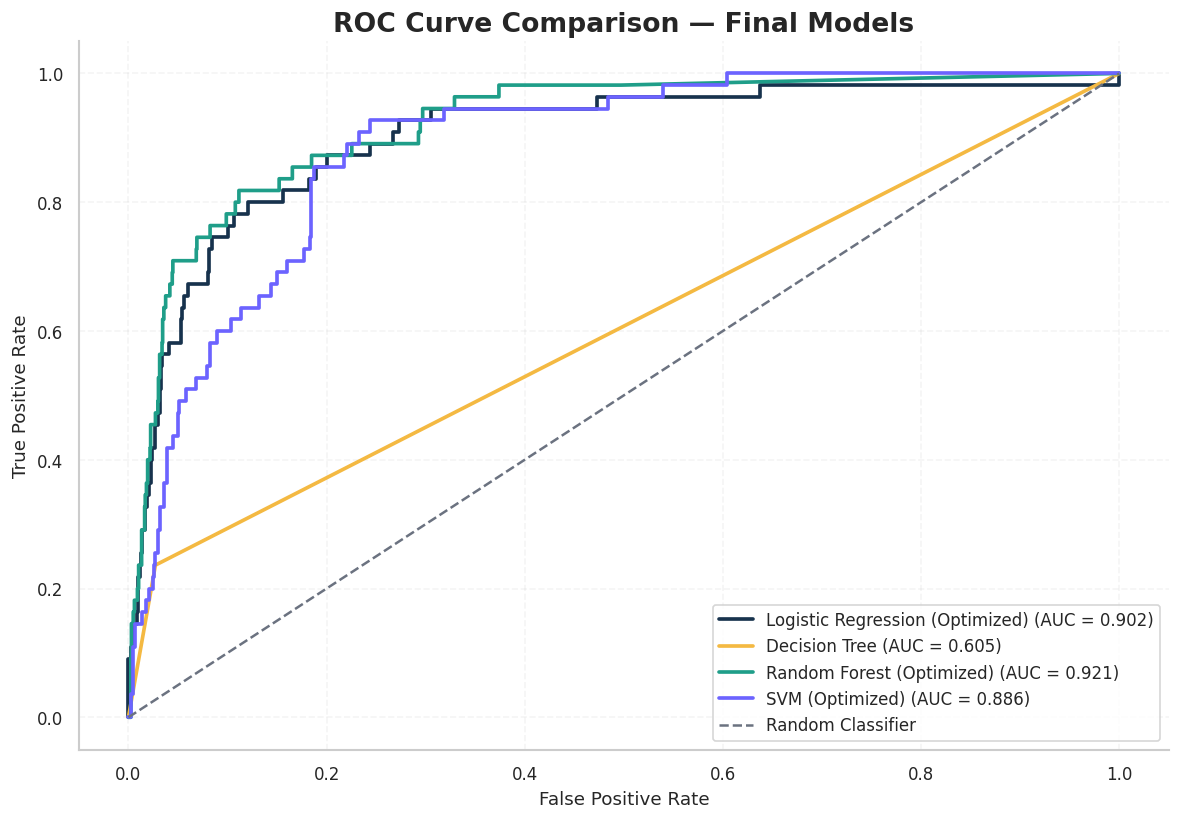

In [ ]:
# ── Evaluation 7.3: ROC curve comparison ───────────────────────────────────

roc_models = {
    'Logistic Regression (Optimized)': y_prob_log_opt,
    'Decision Tree': y_prob_dt,
    'Random Forest (Optimized)': y_prob_rf_opt,
    'SVM (Optimized)': y_prob_svm_opt
}

roc_colors = [
    '#17324D',
    '#F4B942',
    '#1F9E89',
    '#6C63FF'
]

plt.figure(figsize=(10, 7))

for (name, probabilities), color in zip(
    roc_models.items(),
    roc_colors
):

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2.2,
        color=color,
        label=f'{name} (AUC = {auc_score:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='#6B7280',
    label='Random Classifier'
)

plt.title(
    'ROC Curve Comparison — Final Models',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

### ROC-AUC Insight

The ROC curves compare how effectively each model separates bankrupt and non-bankrupt companies across different classification thresholds.

A curve closer to the upper-left corner and a larger ROC-AUC indicate stronger discriminatory ability.

ROC-AUC is considered together with Recall and F1-score because the dataset is highly imbalanced.

In [ ]:
# ── Evaluation 7.4: Cross-validation stability ─────────────────────────────

validation_models = {
    'Logistic Regression': (
        log_best,
        X_train_selected
    ),

    'Random Forest': (
        rf_best,
        X_train_selected_raw
    ),

    'SVM': (
        svm_best,
        X_train_selected
    )
}

validation_results = []

for name, (model, X_data) in validation_models.items():

    f1_scores = cross_val_score(
        model,
        X_data,
        y_train,
        cv=cv_strategy,
        scoring='f1',
        n_jobs=-1
    )

    auc_scores = cross_val_score(
        model,
        X_data,
        y_train,
        cv=cv_strategy,
        scoring='roc_auc',
        n_jobs=-1
    )

    validation_results.append({
        'Model': name,
        'Mean CV F1 (%)': f1_scores.mean() * 100,
        'F1 Std (%)': f1_scores.std() * 100,
        'Mean CV ROC-AUC (%)': auc_scores.mean() * 100,
        'ROC-AUC Std (%)': auc_scores.std() * 100
    })

validation_df = pd.DataFrame(validation_results)

print("=== STRATIFIED 5-FOLD VALIDATION RESULTS ===")

display(
    validation_df.style.format({
        'Mean CV F1 (%)': '{:.2f}',
        'F1 Std (%)': '{:.2f}',
        'Mean CV ROC-AUC (%)': '{:.2f}',
        'ROC-AUC Std (%)': '{:.2f}'
    })
)

=== STRATIFIED 5-FOLD VALIDATION RESULTS ===


,Model,Mean CV F1 (%),F1 Std (%),Mean CV ROC-AUC (%),ROC-AUC Std (%)
0,Logistic Regression,28.65,3.20,93.07,3.51
1,Random Forest,41.67,3.25,91.62,3.20
2,SVM,27.30,2.11,91.01,2.60


In [ ]:
# ── Evaluation 7.5: Identify strongest final-model candidates ──────────────

best_f1_final = final_results_df.loc[
    final_results_df['F1-score'].idxmax()
]

best_recall_final = final_results_df.loc[
    final_results_df['Recall'].idxmax()
]

best_auc_final = final_results_df.loc[
    final_results_df['ROC-AUC'].idxmax()
]

print("=== FINAL MODEL SELECTION EVIDENCE ===")

print(
    f"\nHighest F1-score : "
    f"{best_f1_final['Model']} "
    f"({best_f1_final['F1-score']:.2f}%)"
)

print(
    f"Highest Recall   : "
    f"{best_recall_final['Model']} "
    f"({best_recall_final['Recall']:.2f}%)"
)

print(
    f"Highest ROC-AUC  : "
    f"{best_auc_final['Model']} "
    f"({best_auc_final['ROC-AUC']:.2f}%)"
)

=== FINAL MODEL SELECTION EVIDENCE ===

Highest F1-score : Random Forest (Optimized) (46.75%)
Highest Recall   : Logistic Regression (Optimized) (80.00%)
Highest ROC-AUC  : Random Forest (Optimized) (92.06%)


## Final Model Selection

Based on the combined evaluation results, the **Optimized Random Forest** is selected as the final predictive model.

The model achieved the strongest overall balance between identifying bankrupt companies and limiting false positive predictions. It produced the **highest F1-score** among the evaluated models and also demonstrated strong ROC-AUC performance.

Although Optimized Logistic Regression achieved the highest Recall and detected **44 of the 55 bankrupt companies**, it generated substantially more false positive predictions. In contrast, Optimized Random Forest detected **35 of the 55 bankrupt companies** while producing considerably fewer false alarms.

Therefore, Random Forest provides a more balanced solution for a practical corporate financial-distress early-warning system.

However, if the business objective places an exceptionally high cost on missing a potentially bankrupt company, Optimized Logistic Regression could alternatively be used as a high-sensitivity screening model.

# 8. Business Insights & Recommendations

The predictive analysis provides practical insights into the financial characteristics associated with corporate bankruptcy and demonstrates how predictive analytics can support financial decision-making.

The findings are interpreted from an **Accounting, Finance, and MIS perspective**, focusing on early detection of financial distress and risk-based decision support.

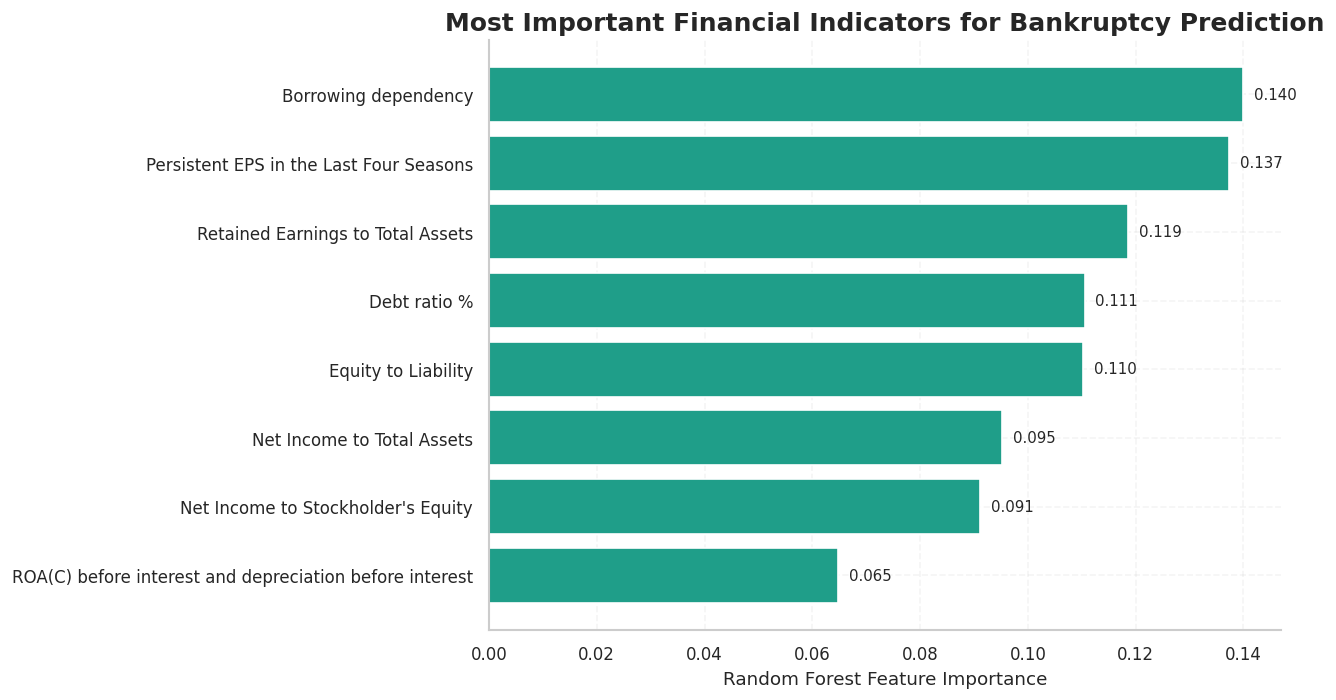

=== TOP FINANCIAL PREDICTORS ===


,Importance
Borrowing dependency,0.1399
Persistent EPS in the Last Four Seasons,0.1374
Retained Earnings to Total Assets,0.1186
Debt ratio %,0.1105
Equity to Liability,0.1103
Net Income to Total Assets,0.0952
Net Income to Stockholder's Equity,0.0911
ROA(C) before interest and depreciation before interest,0.0648


In [ ]:
# ── Insights 8.1: Key bankruptcy predictors ────────────────────────────────

final_importance = pd.Series(
    rf_best.feature_importances_,
    index=X_train_selected_raw.columns
).sort_values(ascending=False)

top_business_features = final_importance.head(8)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_business_features.index[::-1],
    top_business_features.values[::-1],
    color='#1F9E89'
)

plt.title(
    'Most Important Financial Indicators for Bankruptcy Prediction',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Random Forest Feature Importance')
plt.ylabel('')

for bar, value in zip(
    bars,
    top_business_features.values[::-1]
):
    plt.text(
        value + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{value:.3f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("=== TOP FINANCIAL PREDICTORS ===")
display(
    top_business_features
    .to_frame('Importance')
    .round(4)
)

# 8. Business Insights & Recommendations

The predictive analysis provides practical insights into the financial characteristics associated with corporate bankruptcy and demonstrates how predictive analytics can support financial decision-making.

The findings are interpreted from an **Accounting, Finance, and MIS perspective**, focusing on early detection of financial distress and risk-based decision support.

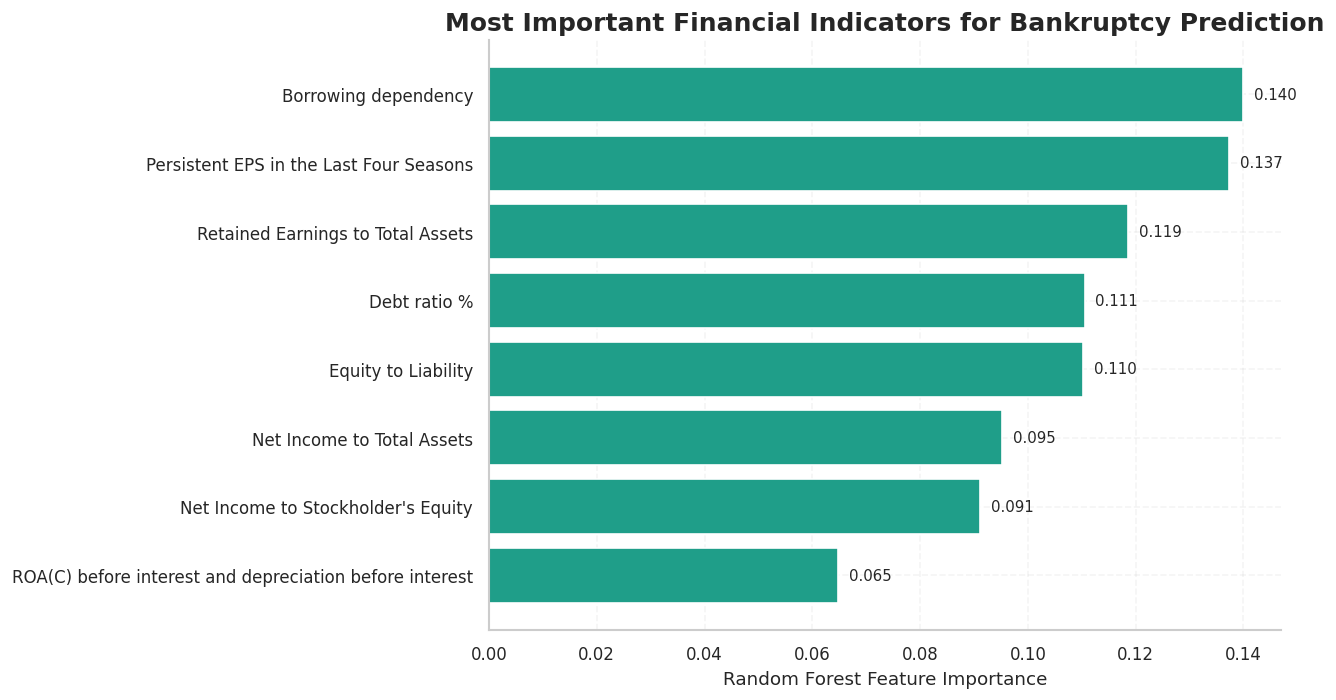

=== TOP FINANCIAL PREDICTORS ===


,Importance
Borrowing dependency,0.1399
Persistent EPS in the Last Four Seasons,0.1374
Retained Earnings to Total Assets,0.1186
Debt ratio %,0.1105
Equity to Liability,0.1103
Net Income to Total Assets,0.0952
Net Income to Stockholder's Equity,0.0911
ROA(C) before interest and depreciation before interest,0.0648


In [ ]:
# ── Insights 8.1: Key bankruptcy predictors ────────────────────────────────

final_importance = pd.Series(
    rf_best.feature_importances_,
    index=X_train_selected_raw.columns
).sort_values(ascending=False)

top_business_features = final_importance.head(8)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_business_features.index[::-1],
    top_business_features.values[::-1],
    color='#1F9E89'
)

plt.title(
    'Most Important Financial Indicators for Bankruptcy Prediction',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Random Forest Feature Importance')
plt.ylabel('')

for bar, value in zip(
    bars,
    top_business_features.values[::-1]
):
    plt.text(
        value + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{value:.3f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("=== TOP FINANCIAL PREDICTORS ===")
display(
    top_business_features
    .to_frame('Importance')
    .round(4)
)

### Key Financial Insight

The final Random Forest model indicates that bankruptcy risk is influenced by a combination of profitability, leverage, liquidity, and financial-structure indicators rather than by a single accounting ratio.

Earlier EDA also showed that:

- Lower **Net Income to Total Assets** is associated with greater bankruptcy risk.
- Lower **Return on Assets (ROA)** is associated with financial distress.
- Higher **Debt Ratio** is associated with greater bankruptcy risk.
- Higher liability pressure is more common among bankrupt companies.
- Companies in the highest debt-ratio quartile had a substantially higher bankruptcy rate than companies in the lowest quartile.

These findings suggest that weakening profitability combined with increasing financial obligations can provide useful early-warning signals.

## 8.2 How Businesses Can Apply This Model

### 1. Banks & Credit Risk Assessment

Banks and financial institutions can use the model as an early-warning tool when evaluating corporate borrowers. Companies classified as higher risk can be subjected to additional financial review before loans are approved, renewed, or extended.

### 2. Auditing & Going-Concern Assessment

Auditors can use bankruptcy-risk predictions as a supplementary analytical procedure when identifying companies that may require closer examination of liquidity, leverage, profitability, and going-concern assumptions.

### 3. Investors & Portfolio Risk Management

Investors and portfolio managers can incorporate predicted financial-distress risk into investment screening. Firms showing elevated bankruptcy risk may require deeper fundamental analysis before investment decisions are made.

### 4. Corporate Management & Internal Control

Finance managers and CFOs can monitor key financial indicators and use the model as part of an internal financial-health dashboard. Early identification of deteriorating ratios may allow management to restructure debt, strengthen liquidity, reduce costs, or improve working-capital management.

### 5. Suppliers & Trade-Credit Decisions

Suppliers offering goods on credit can use financial-distress predictions to identify customers with elevated default risk and adjust credit limits, payment terms, or monitoring requirements accordingly.

## 8.3 Model Selection Summary

The **Optimized Random Forest** is selected as the primary final model for the corporate bankruptcy early-warning system.

The selection is based on the combined evaluation results:

- It achieved the **highest F1-score**, providing the strongest overall balance between Precision and Recall.
- It demonstrated strong **ROC-AUC**, indicating good ability to distinguish bankrupt from non-bankrupt companies.
- It generated substantially fewer false alarms than the high-recall Logistic Regression model.
- Cross-validation was used during model development to assess performance across different training subsets.
- As an ensemble model, Random Forest can capture complex and non-linear relationships among financial indicators.

However, **Optimized Logistic Regression** achieved the highest Recall. Therefore, if an organization places an exceptionally high cost on failing to identify a distressed company, Logistic Regression could be used as a more sensitive first-stage screening model.

The appropriate model therefore depends partly on the business cost of **False Negatives versus False Positives**.

## 8.4 Limitations & Future Improvements

| Limitation | Suggested Improvement |
|---|---|
| Dataset represents Taiwanese companies and may not fully generalize to firms in other countries | Validate the model using datasets from multiple countries and industries |
| Bankrupt companies represent only 3.23% of observations | Test additional imbalance-handling methods and probability-threshold optimization |
| The model relies primarily on historical financial indicators | Incorporate macroeconomic, market, governance, and qualitative information |
| Financial relationships may change over time | Use newer datasets and periodically retrain the model |
| False Positives and False Negatives carry different business costs | Apply cost-sensitive classification and business-specific decision thresholds |
| Random Forest predictions are less directly interpretable than Logistic Regression | Apply explainability techniques such as SHAP to explain individual risk predictions |

In [ ]:
# ── Final Project Summary ──────────────────────────────────────────────────

best_final = final_results_df.loc[
    final_results_df['F1-score'].idxmax()
]

print("=" * 68)
print("        MIS444 — CORPORATE BANKRUPTCY PREDICTION SUMMARY")
print("=" * 68)

print(f" Dataset records            : 6,819 companies")
print(f" Raw dataset predictors     : 95")
print(f" Predictors after cleaning  : 94")
print(f" Final selected predictors  : {len(final_features)}")
print(f" Problem type               : Binary Classification")

print("\n Models Trained:")
print(" Logistic Regression")
print(" Decision Tree")
print(" Random Forest")
print(" Support Vector Machine")

print("\n Optimization:")
print(" GridSearchCV + Stratified 5-Fold Cross-Validation")

print("\n Final Model:")
print(f" {best_final['Model']}")

print("\n Final Test Performance:")
print(f" Accuracy   : {best_final['Accuracy']:.2f}%")
print(f" Precision  : {best_final['Precision']:.2f}%")
print(f" Recall     : {best_final['Recall']:.2f}%")
print(f" F1-score   : {best_final['F1-score']:.2f}%")
print(f" ROC-AUC    : {best_final['ROC-AUC']:.2f}%")

print("=" * 68)

        MIS444 — CORPORATE BANKRUPTCY PREDICTION SUMMARY
 Dataset records            : 6,819 companies
 Raw dataset predictors     : 95
 Predictors after cleaning  : 94
 Final selected predictors  : 11
 Problem type               : Binary Classification

 Models Trained:
 Logistic Regression
 Decision Tree
 Random Forest
 Support Vector Machine

 Optimization:
 GridSearchCV + Stratified 5-Fold Cross-Validation

 Final Model:
 Random Forest (Optimized)

 Final Test Performance:
 Accuracy   : 95.19%
 Precision  : 36.36%
 Recall     : 65.45%
 F1-score   : 46.75%
 ROC-AUC    : 92.06%


# Final Conclusion

This project developed a predictive analytics framework for identifying corporate bankruptcy risk using financial indicators.

The analysis showed that financial distress is associated with a combination of **weaker profitability, greater leverage, and increased liability pressure**. Multiple classification algorithms were developed, optimized, and validated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Among the evaluated models, the **Optimized Random Forest** provided the strongest overall balance between detecting bankrupt companies and controlling false positive predictions.

The model can support banks, auditors, investors, corporate managers, and trade-credit providers as an **early-warning decision-support system**. However, model predictions should complement—not replace—professional financial analysis and judgment.

Future work could improve generalizability by incorporating more recent international data, macroeconomic variables, time-based financial information, model explainability, and business-specific classification thresholds.